## 1. Leitura do arquivo CSV

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#ler o arquivo
df = pd.read_csv("dados_combinados.csv", sep="," , encoding='utf-8')
display(df.head())

,id,site,unidade,vida,igv_abertura,bov_fechada,pre_sistema,pre_descarga,pre_oleo,vibracao_1,...,aux_oil_pump_trip,vibration_1_high_alarm,press_oil_l,vibration_2_high_alarm,vibration_3_high_alarm,motor_current_l,oil_supply_temp_high,estag_3_inlet_temp_high,oil_reservoir_temp_l,timestamp
0,1,teste,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-04-16 14:03:14
1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.953125,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-04-16 14:03:14
2,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.937500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-04-16 14:03:14
3,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.968750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-04-16 14:03:14
4,5,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.875000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2025-04-16 14:03:14


## 2. Verificar a correlação entre as variáveis

In [4]:
correlacao = df.drop(columns=['id']).corr(numeric_only=True) # Calculando a correlação entre as colunas numéricas
display(correlacao)

,unidade,vida,igv_abertura,bov_fechada,pre_sistema,pre_descarga,pre_oleo,vibracao_1,vibracao_2,vibracao_3,...,trip,aux_oil_pump_trip,vibration_1_high_alarm,press_oil_l,vibration_2_high_alarm,vibration_3_high_alarm,motor_current_l,oil_supply_temp_high,estag_3_inlet_temp_high,oil_reservoir_temp_l
unidade,1.000000,0.892028,0.296797,0.291988,0.323302,0.296269,0.304865,0.007941,0.002929,-0.003365,...,0.012753,NaN,0.022386,NaN,0.022727,NaN,NaN,NaN,NaN,NaN
vida,0.892028,1.000000,0.332722,0.327330,0.362435,0.332130,0.341767,0.007341,0.002779,-0.005355,...,0.014297,NaN,0.025096,NaN,0.025478,NaN,NaN,NaN,NaN,NaN
igv_abertura,0.296797,0.332722,1.000000,0.985159,0.920229,0.996612,0.990587,0.830858,0.895089,0.903217,...,-0.858589,NaN,0.074857,NaN,0.076206,NaN,NaN,NaN,NaN,NaN
bov_fechada,0.291988,0.327330,0.985159,1.000000,0.905170,0.989786,0.975934,0.815712,0.883498,0.889028,...,-0.844676,NaN,0.063283,NaN,0.063165,NaN,NaN,NaN,NaN,NaN
pre_sistema,0.323302,0.362435,0.920229,0.905170,1.000000,0.916978,0.943345,0.768263,0.818387,0.829960,...,-0.919043,NaN,0.069544,NaN,0.070589,NaN,NaN,NaN,NaN,NaN
pre_descarga,0.296269,0.332130,0.996612,0.989786,0.916978,1.000000,0.986646,0.824491,0.891799,0.899637,...,-0.854772,NaN,0.073420,NaN,0.074570,NaN,NaN,NaN,NaN,NaN
pre_oleo,0.304865,0.341767,0.990587,0.975934,0.943345,0.986646,1.000000,0.827700,0.888971,0.899803,...,-0.877469,NaN,0.014466,NaN,0.015244,NaN,NaN,NaN,NaN,NaN
vibracao_1,0.007941,0.007341,0.830858,0.815712,0.768263,0.824491,0.827700,1.000000,0.977777,0.967719,...,-0.828462,NaN,0.077387,NaN,0.078488,NaN,NaN,NaN,NaN,NaN
vibracao_2,0.002929,0.002779,0.895089,0.883498,0.818387,0.891799,0.888971,0.977777,1.000000,0.990411,...,-0.883904,NaN,0.072346,NaN,0.070988,NaN,NaN,NaN,NaN,NaN
vibracao_3,-0.003365,-0.005355,0.903217,0.889028,0.829960,0.899637,0.899803,0.967719,0.990411,1.000000,...,-0.898701,NaN,0.074882,NaN,0.074623,NaN,NaN,NaN,NaN,NaN


## 3. Plotar o mapa de calor (heatmap) da correlação

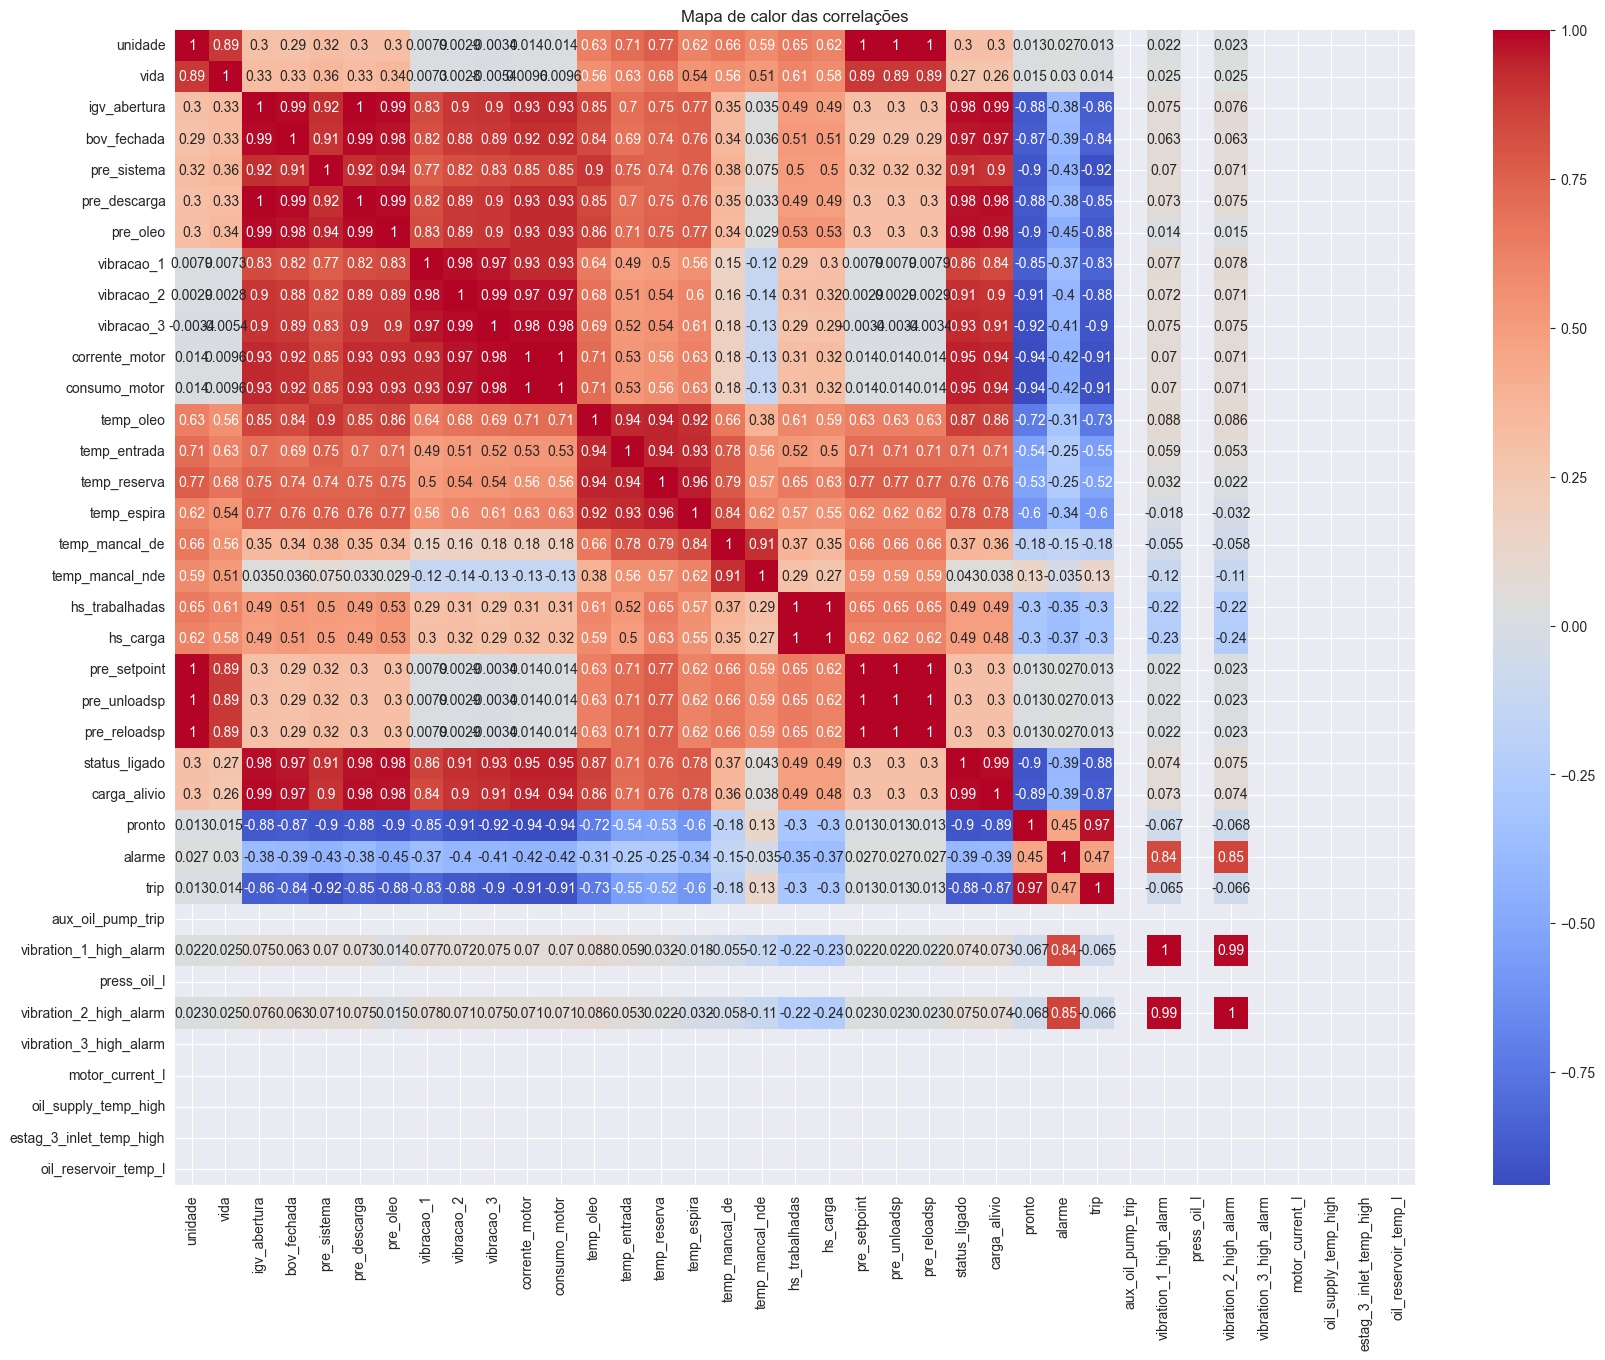

In [5]:
plt.figure(figsize=(20, 15))
sns.heatmap(correlacao, annot=True, cmap="coolwarm")
plt.title("Mapa de calor das correlações")
plt.show()

## 4. Verificar colunas com muitos valores zero     

In [6]:
zero_por_colunas = (df == 0).sum()                      # Contar a quantidade de zeros por colunas
display(zero_por_colunas.sort_values(ascending=False))  # Exibindo as colunas com muitos zeros

oil_supply_temp_high       10708
aux_oil_pump_trip          10708
estag_3_inlet_temp_high    10708
motor_current_l            10708
vibration_3_high_alarm     10708
press_oil_l                10708
oil_reservoir_temp_l       10708
trip                       10327
pronto                     10306
vibration_1_high_alarm      9615
vibration_2_high_alarm      9585
alarme                      9210
bov_fechada                  512
igv_abertura                 507
carga_alivio                 500
status_ligado                492
pre_oleo                      66
vida                          59
pre_sistema                   59
pre_descarga                  59
temp_reserva                  47
temp_espira                   47
unidade                       47
temp_entrada                  47
pre_reloadsp                  47
temp_oleo                     47
temp_mancal_de                47
temp_mancal_nde               47
hs_trabalhadas                47
pre_unloadsp                  47
hs_carga  

## 5. Excluir colunas que têm apenas zeros

In [7]:
df = df.loc[:, (df !=0).any(axis=0)] # removendo as colunas com todos os valores zerados

## 6. Verificar linhas com muitos zeros 

In [8]:
zero_por_linhas = (df == 0).sum(axis=1)                 # Contando a quantidade de zeros por linhas
display(zero_por_linhas.sort_values(ascending=False))   # Exibindo as linhas com valores zerados

0       30
2       27
3       27
1       27
27      25
        ..
2841     2
2842     2
2843     2
2844     2
2845     2
Length: 10708, dtype: int64

## 7. Excluir linhas com muitos zeros (Adicionei o limite de 20 zeros)

In [9]:
limite_de_zeros = 20
df = df[zero_por_linhas <= limite_de_zeros] # Excluindo as linha que estão abaixo do limite de zeros.

##  8. Gráficos

### 8.1 Mapa de calor 

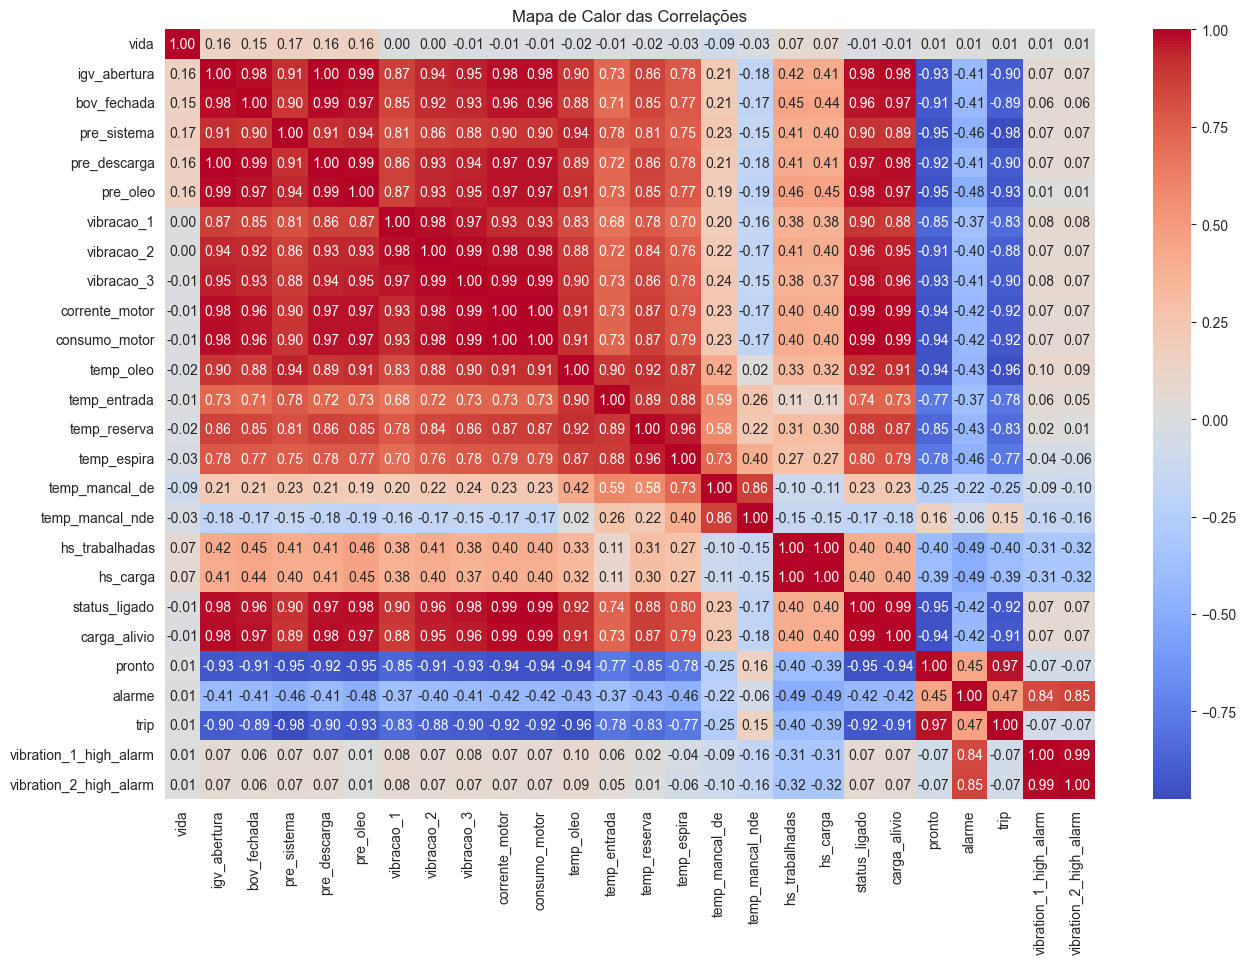

In [10]:
plt.figure(figsize=(15,10))
# As colunas unidade, pre_setpoint, pre_unloadsp e pre_reloadsp tem valores iguais, impossibilitando o cálculo de correlação
sns.heatmap(df.drop(columns=['id', 'unidade', 'pre_setpoint', 'pre_unloadsp', 'pre_reloadsp']).corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor das Correlações')
plt.show()

### 8.2 Histograma

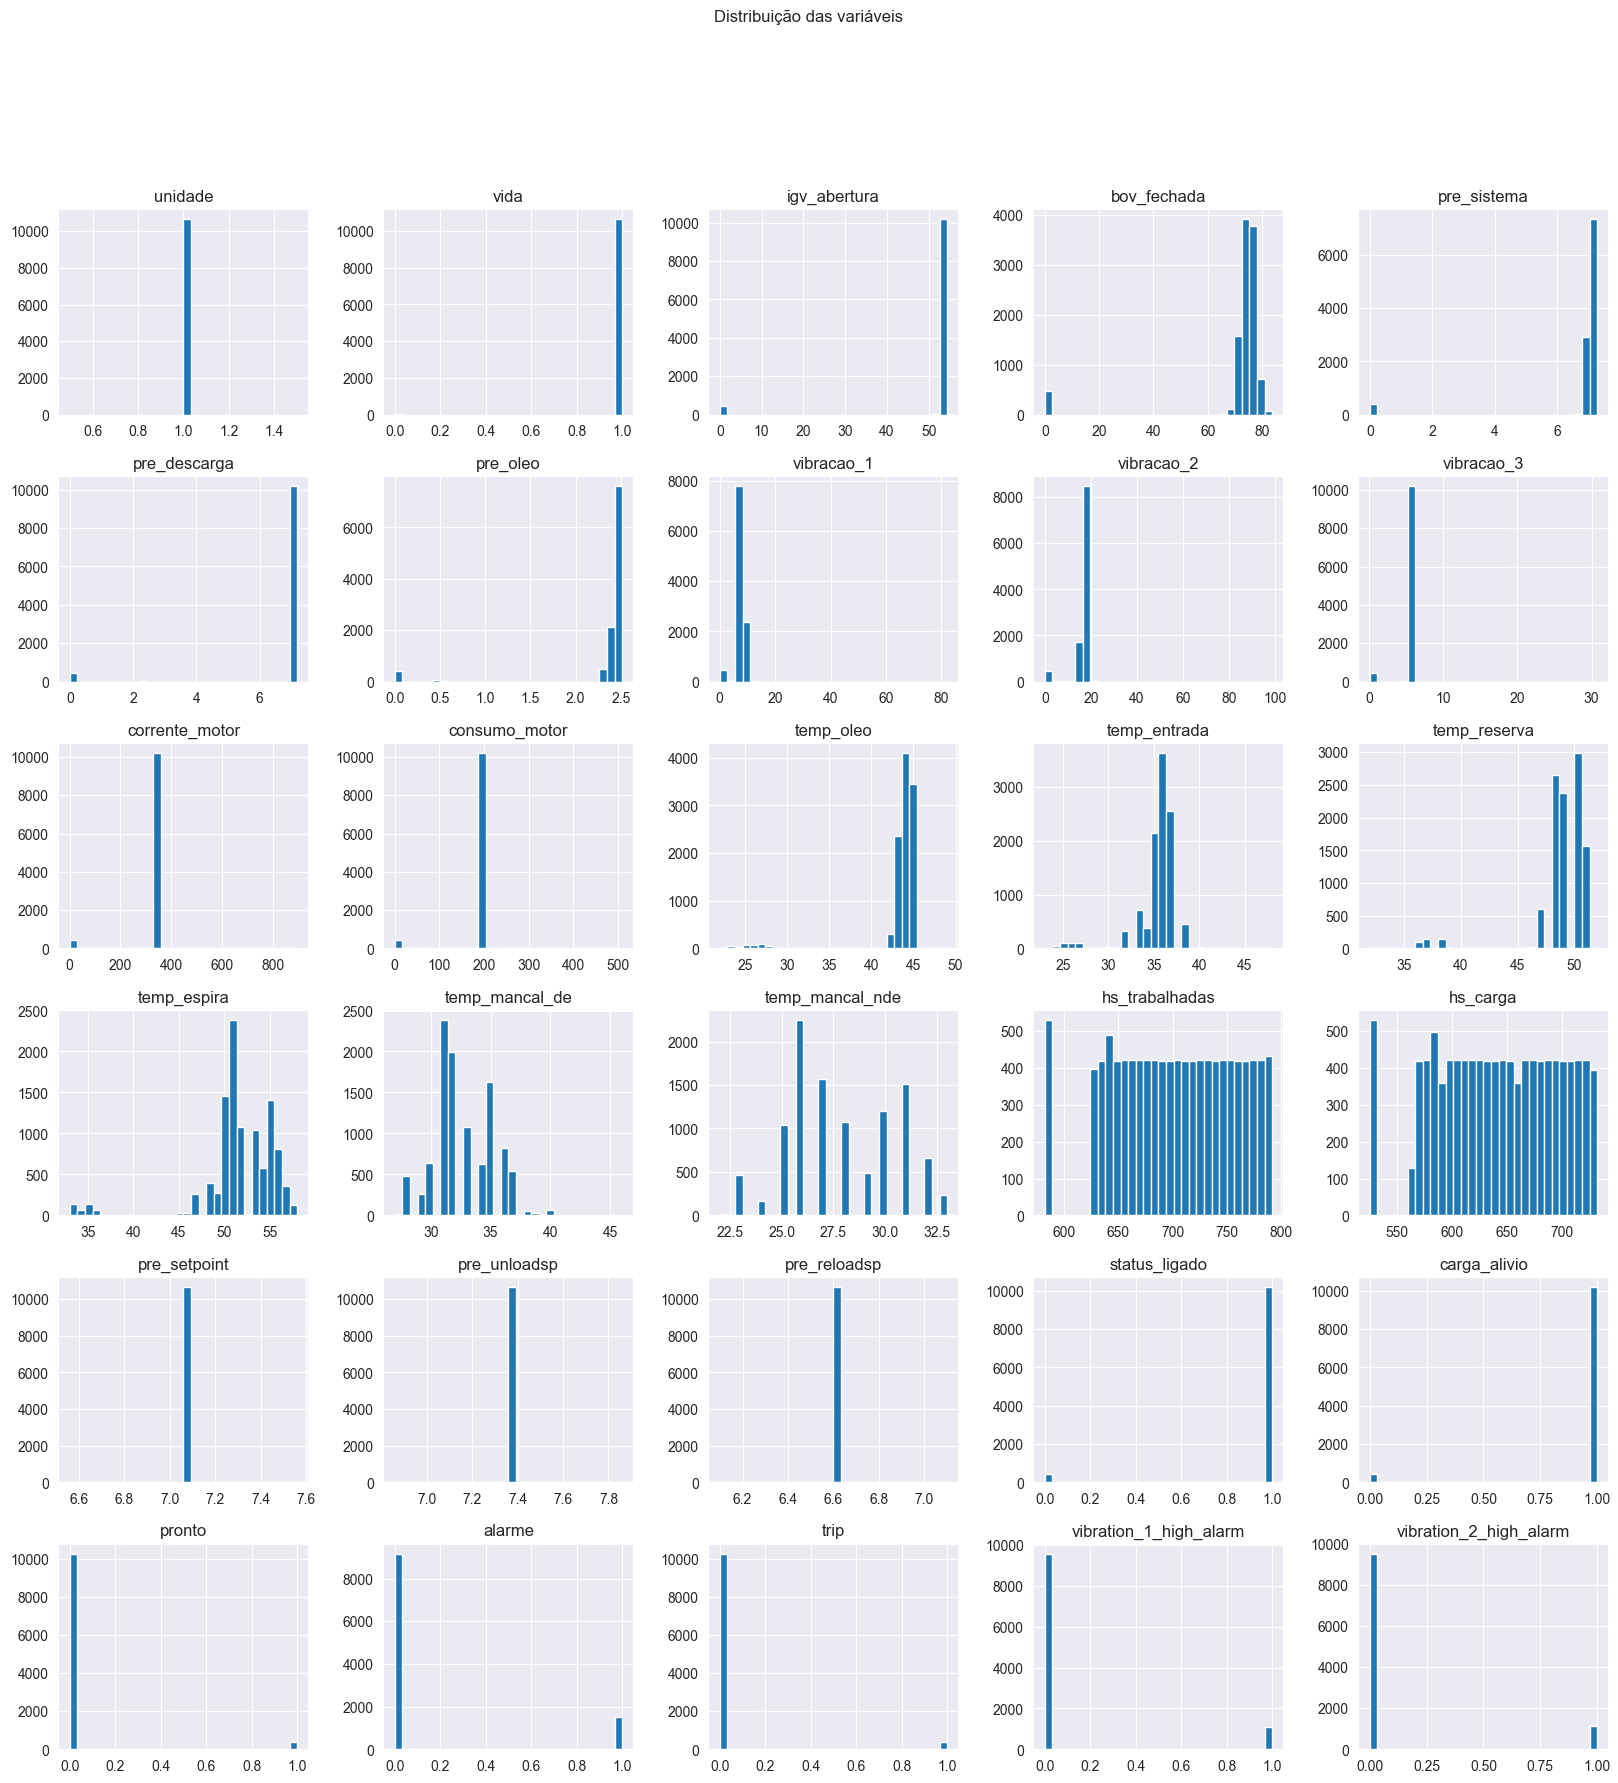

In [11]:
df.drop(columns=['id']).hist(figsize=(20, 20), bins=30)
plt.suptitle("Distribuição das variáveis")
plt.show()

### 8.3 Boxplot

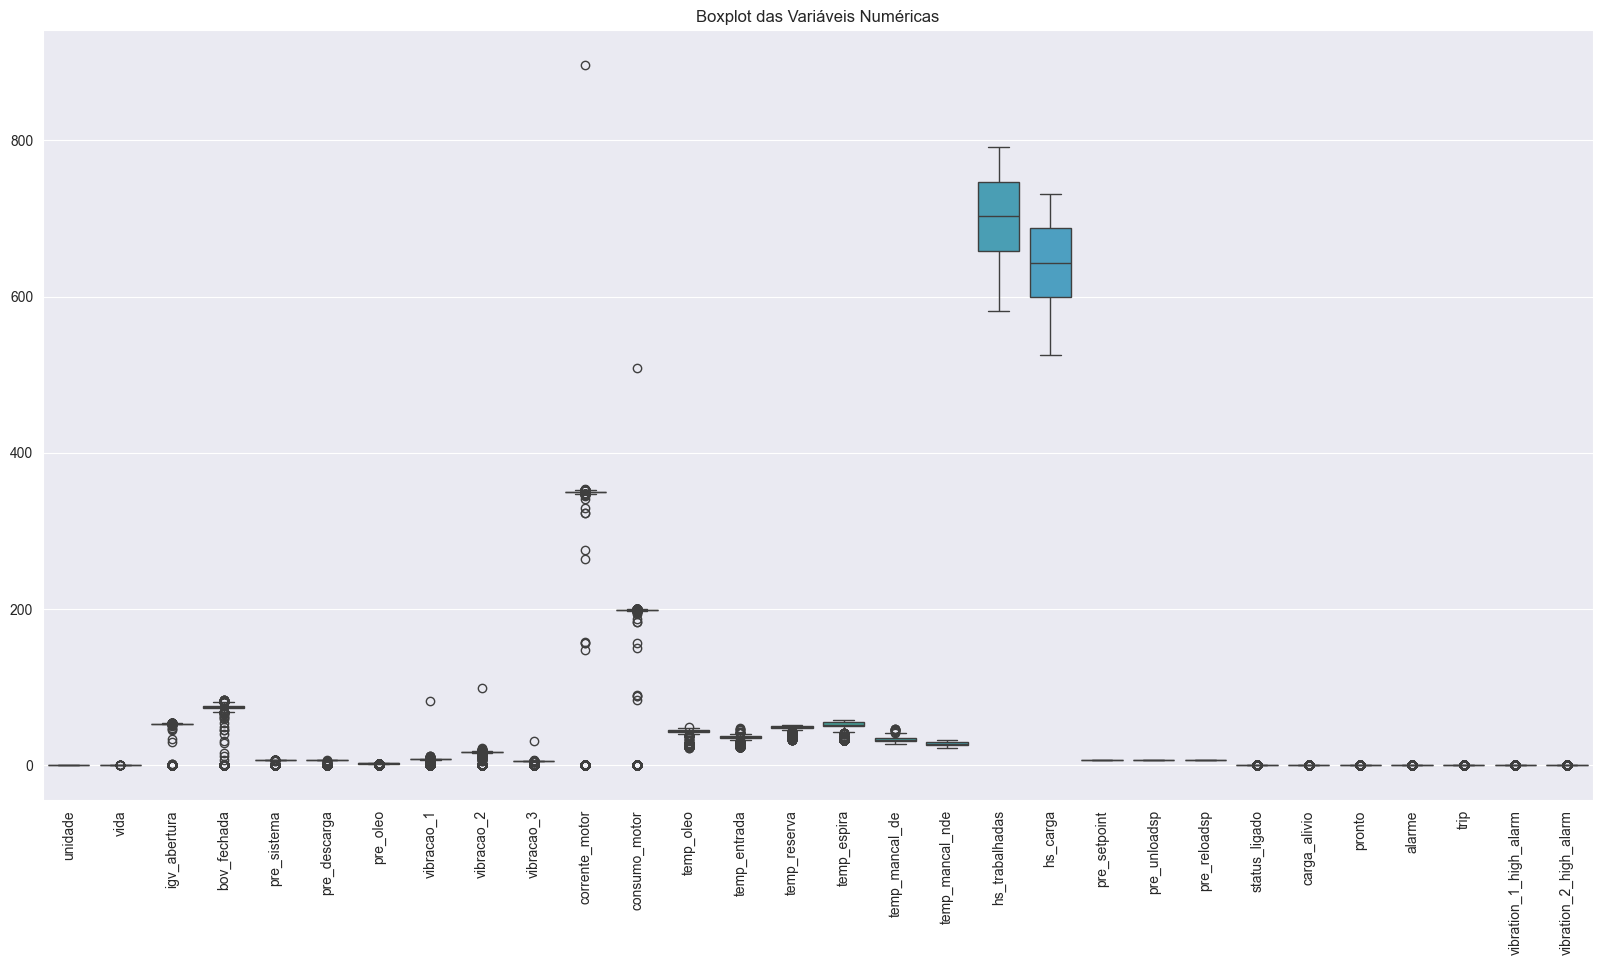

In [12]:
plt.figure(figsize=(20,10))
sns.boxplot(data=df.drop(columns=['id']).select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.title("Boxplot das Variáveis Numéricas")
plt.show()

### 8.4 Gráficos de Dispersão

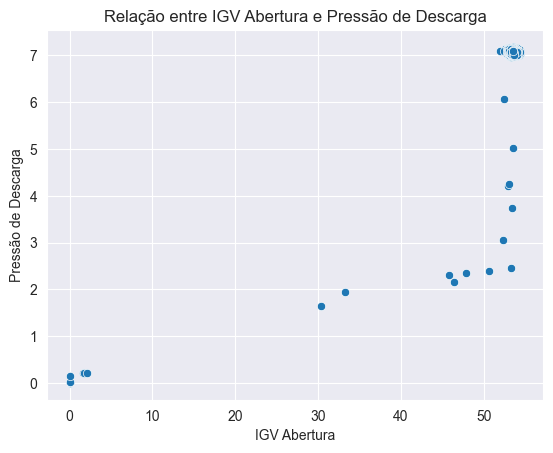

In [13]:
sns.scatterplot(data=df, x='igv_abertura', y='pre_descarga')
plt.title('Relação entre IGV Abertura e Pressão de Descarga')
plt.xlabel('IGV Abertura')
plt.ylabel('Pressão de Descarga')
plt.show()


Não foram encontradas variáveis fortemente correlacionadas com 'unidade' (correlação absoluta > 0.5).
Não foram encontradas variáveis fortemente correlacionadas com 'vida' (correlação absoluta > 0.5).


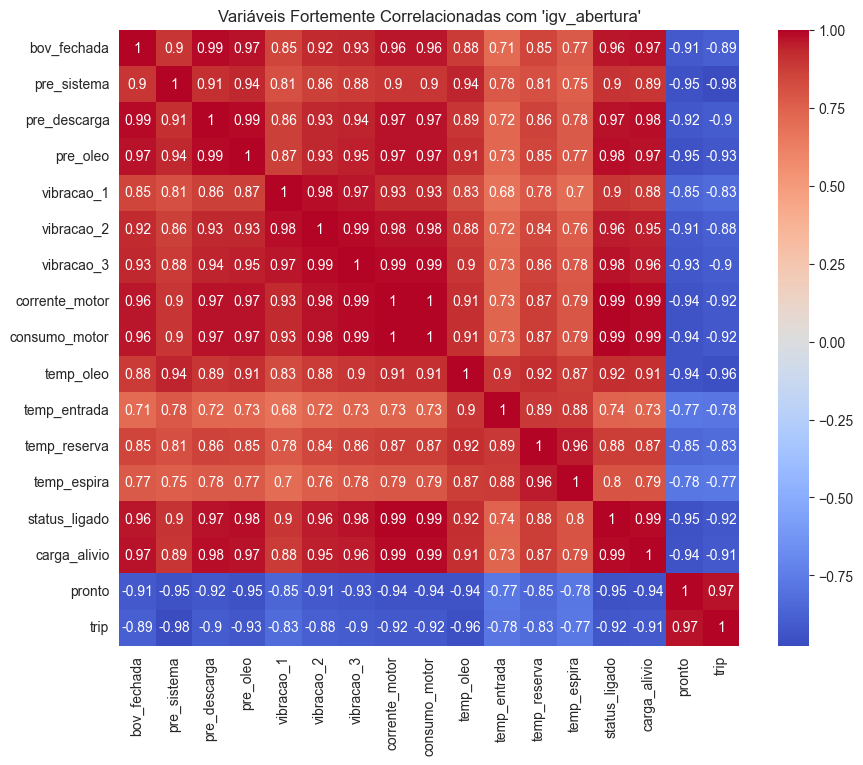

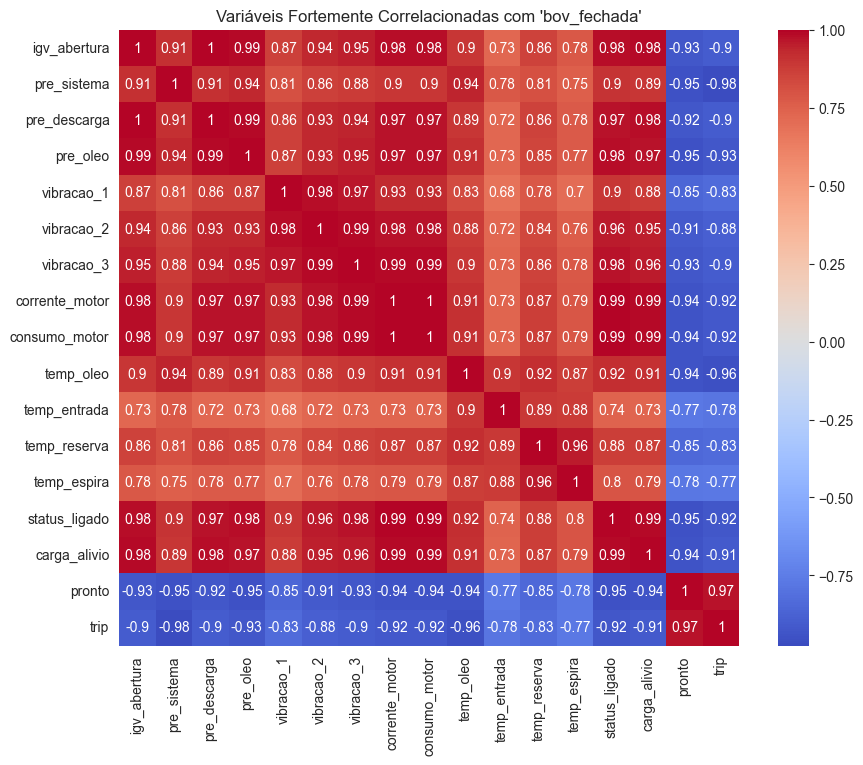

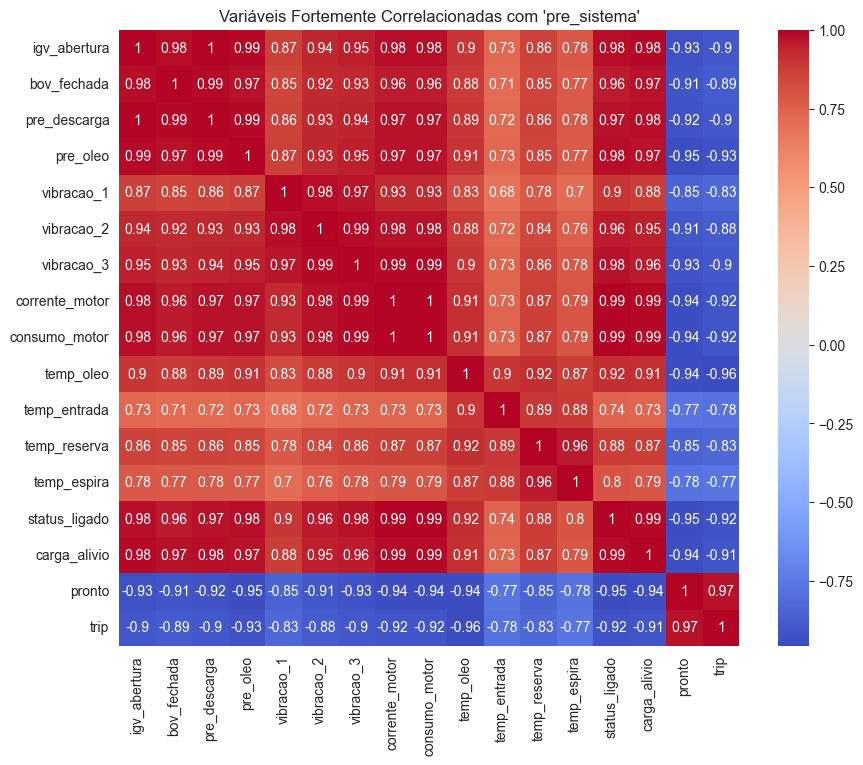

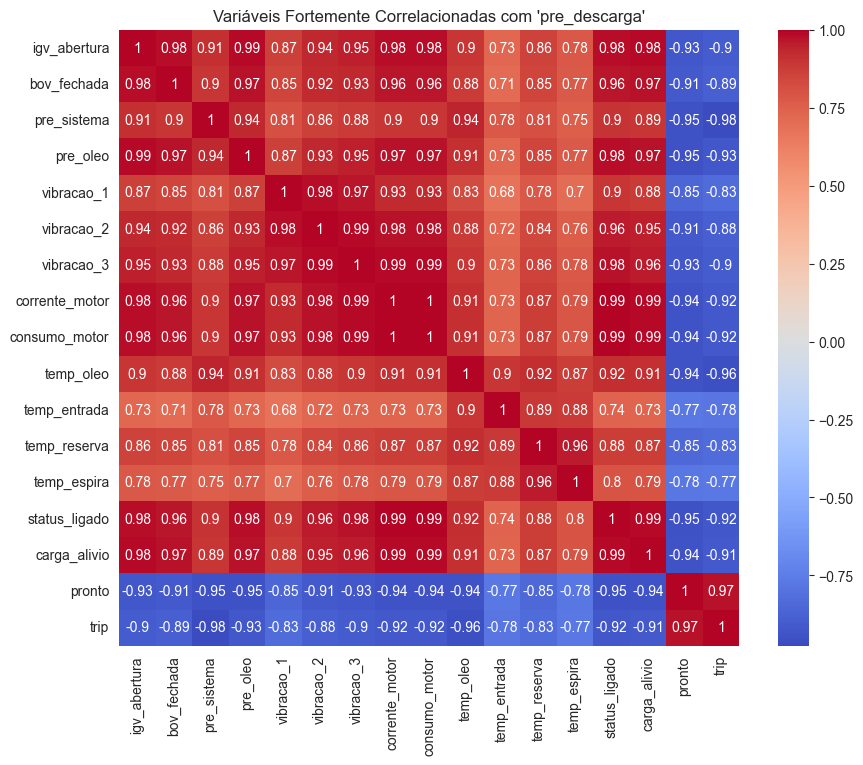

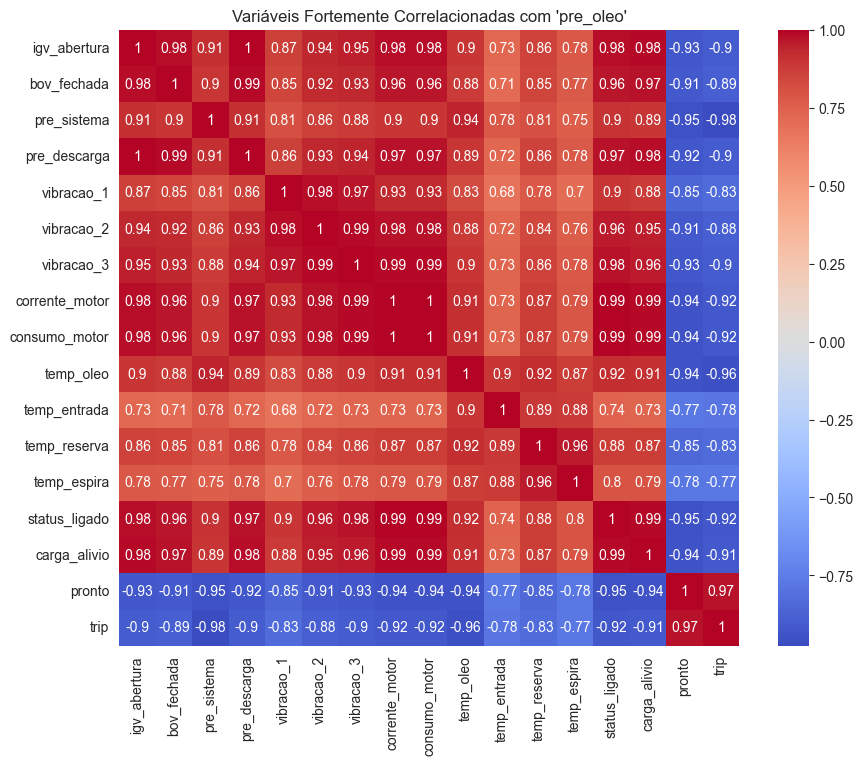

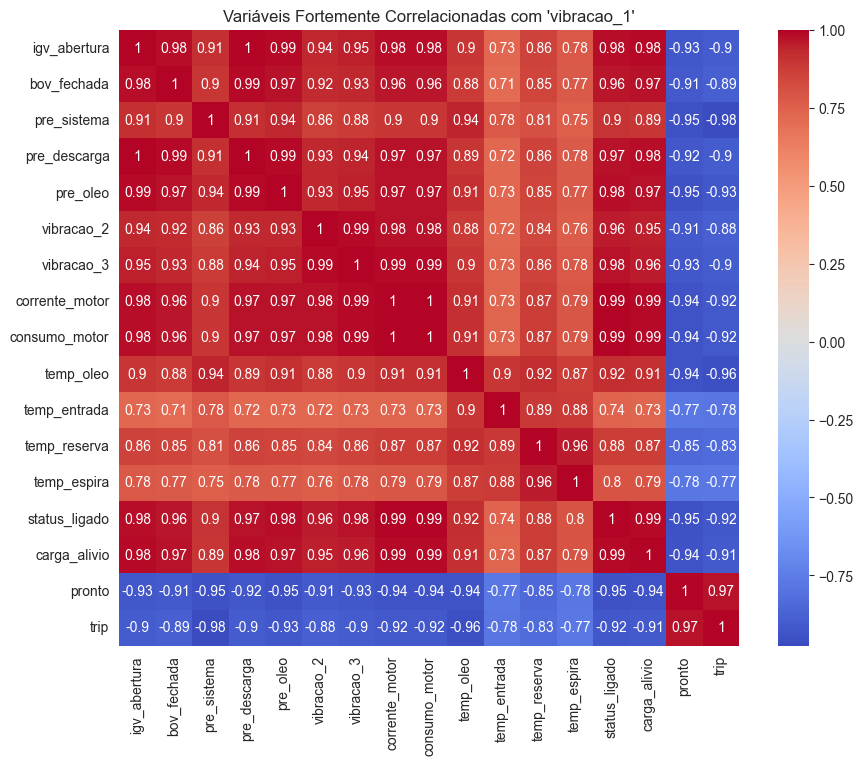

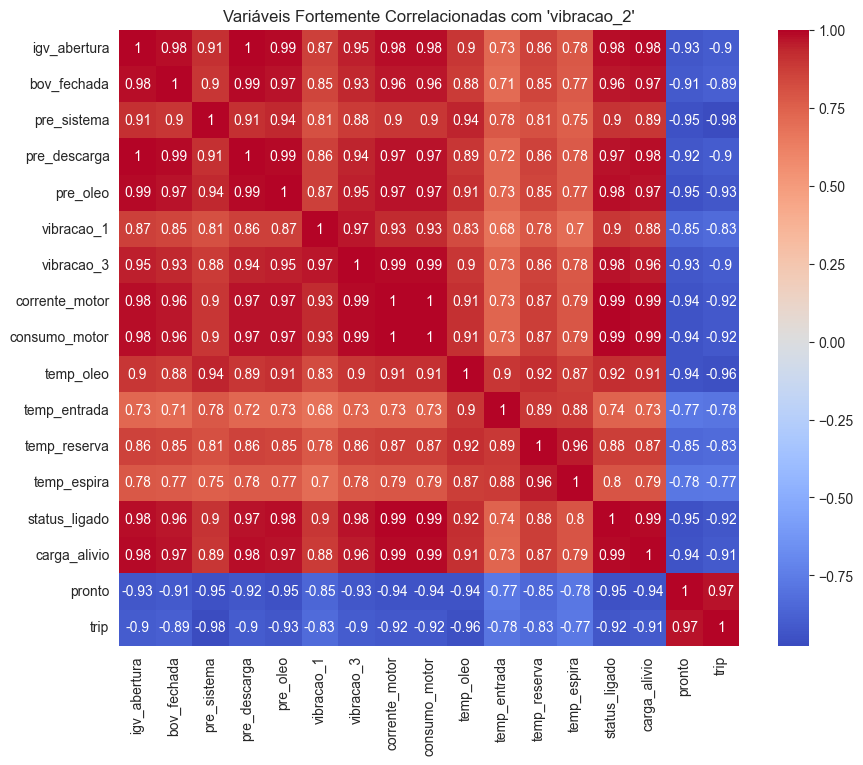

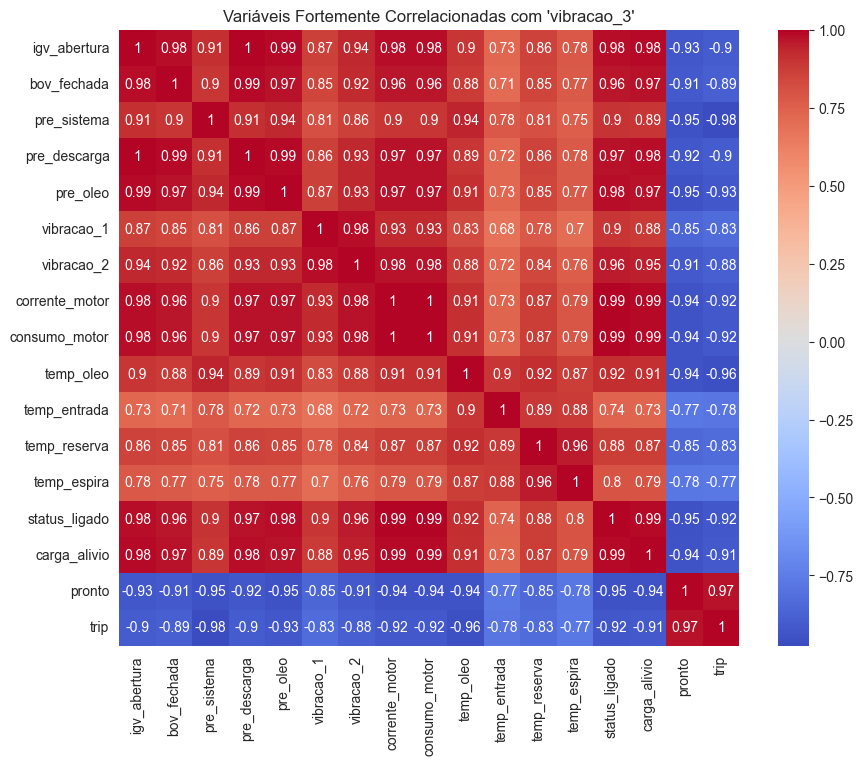

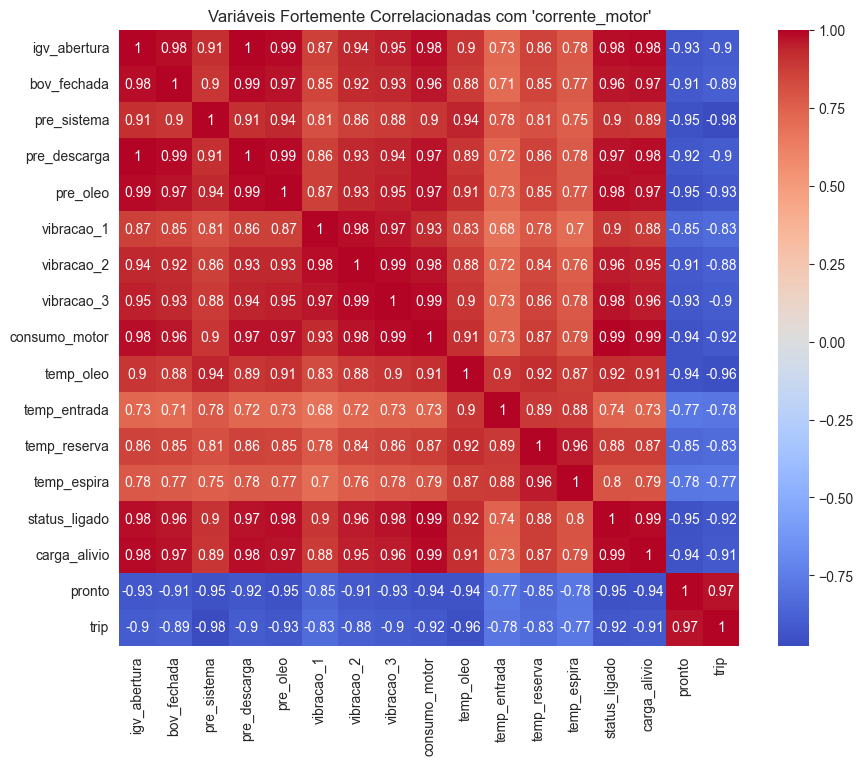

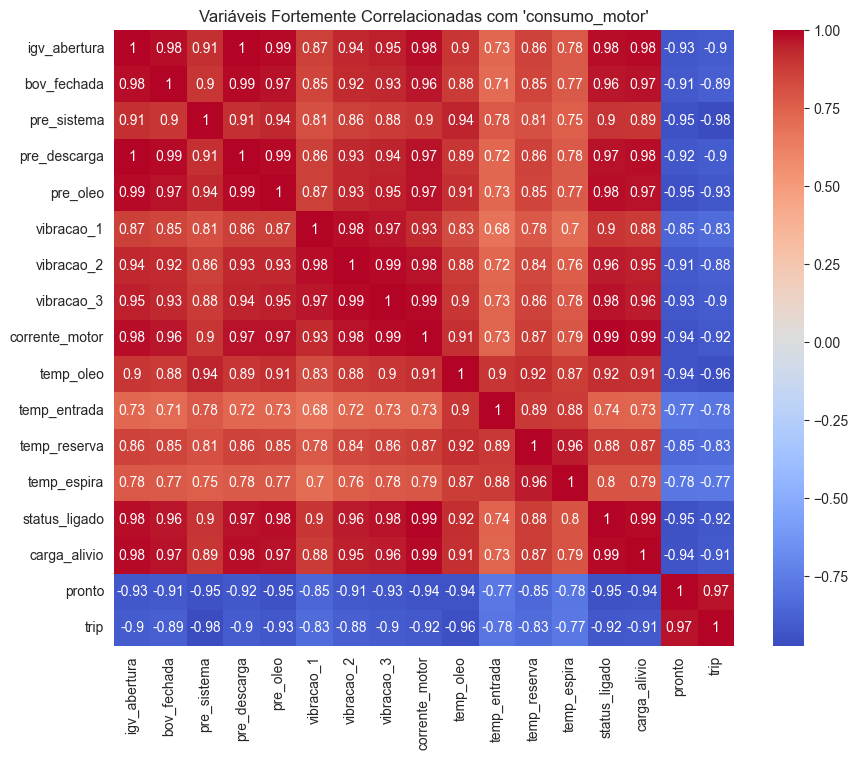

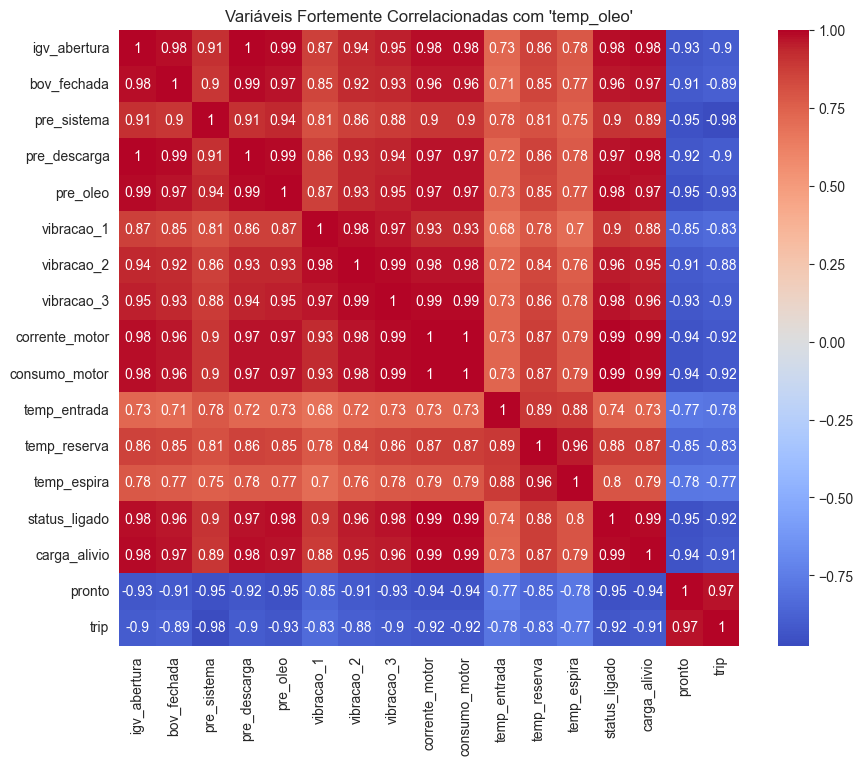

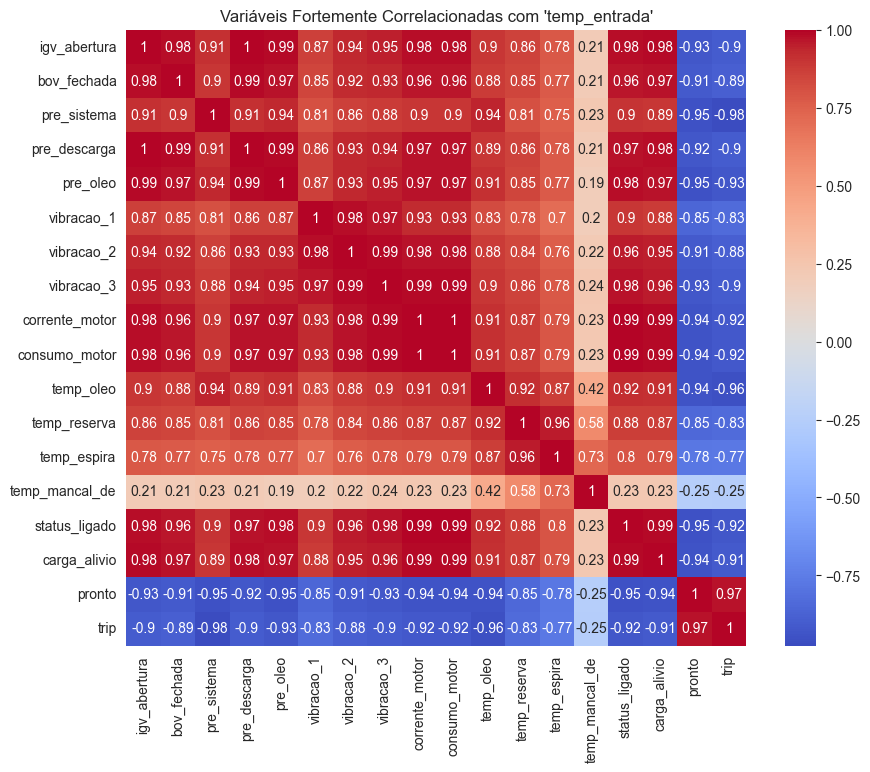

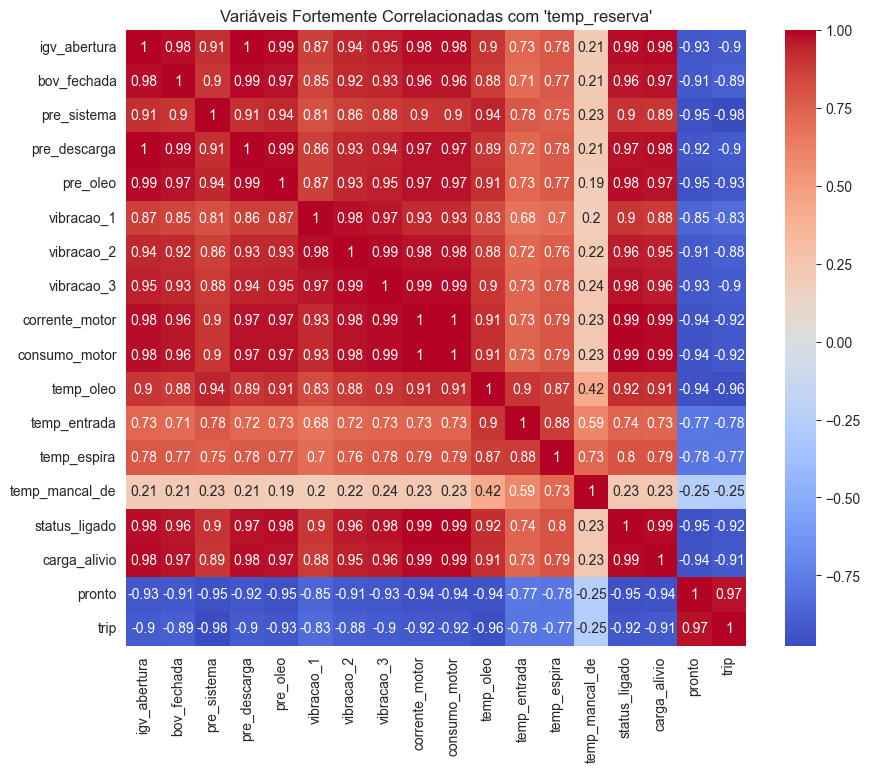

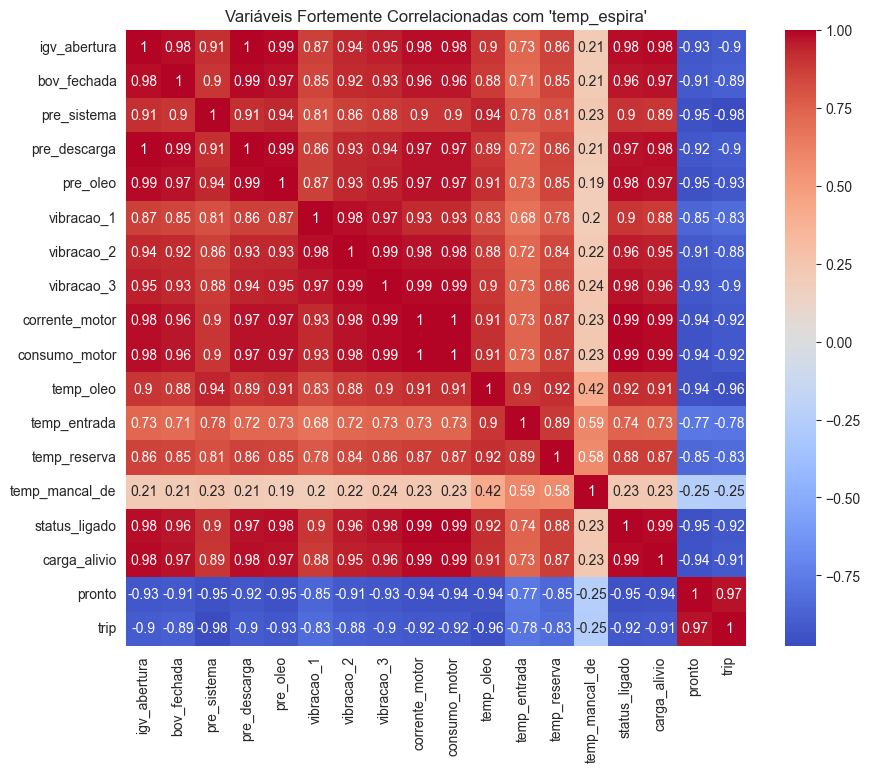

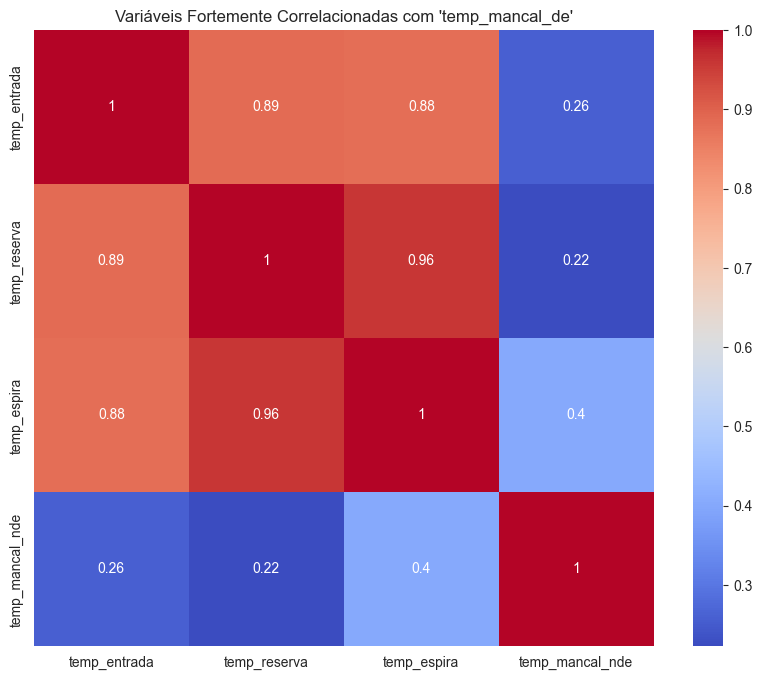

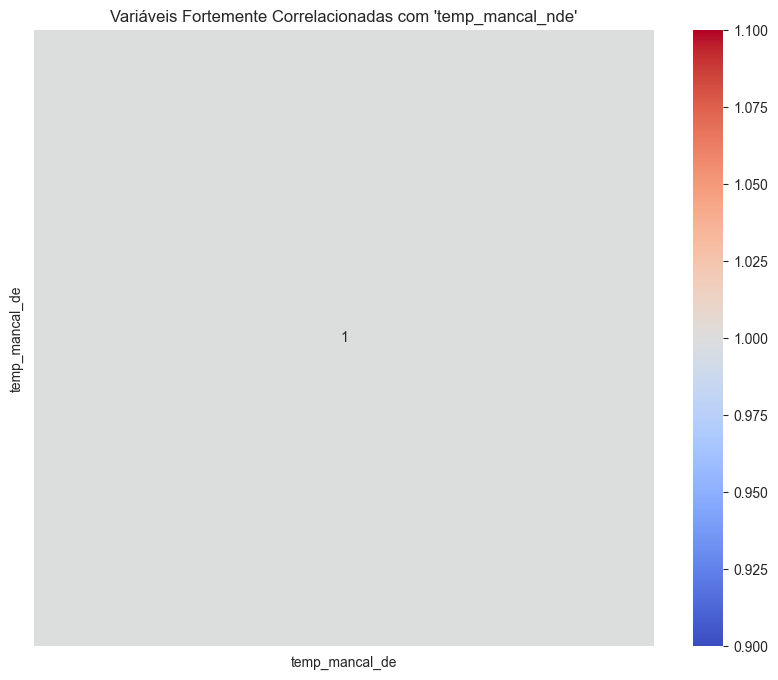

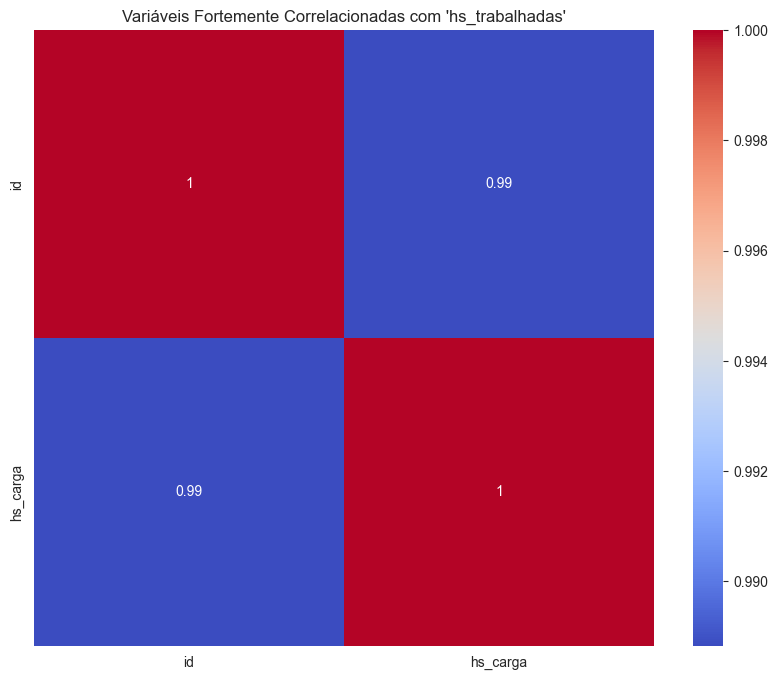

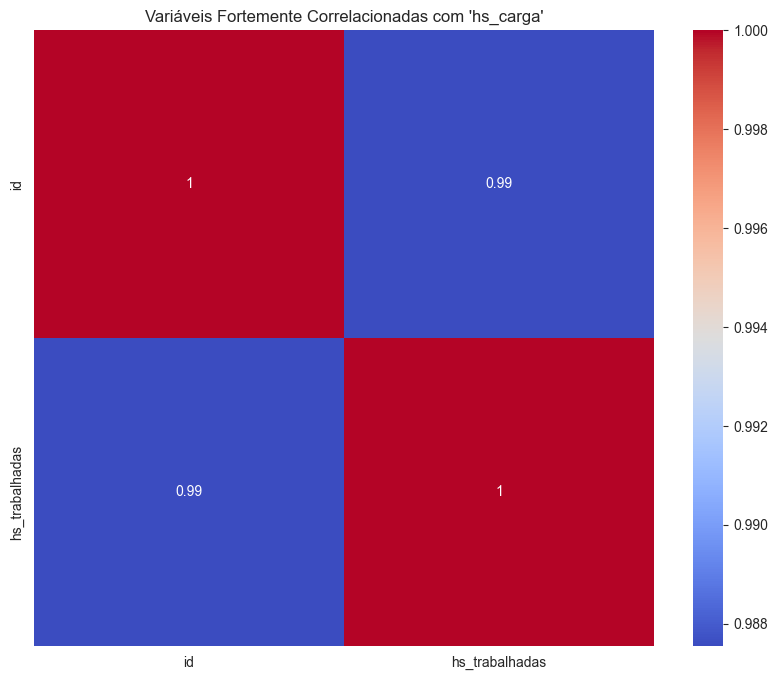

Não foram encontradas variáveis fortemente correlacionadas com 'pre_setpoint' (correlação absoluta > 0.5).
Não foram encontradas variáveis fortemente correlacionadas com 'pre_unloadsp' (correlação absoluta > 0.5).
Não foram encontradas variáveis fortemente correlacionadas com 'pre_reloadsp' (correlação absoluta > 0.5).


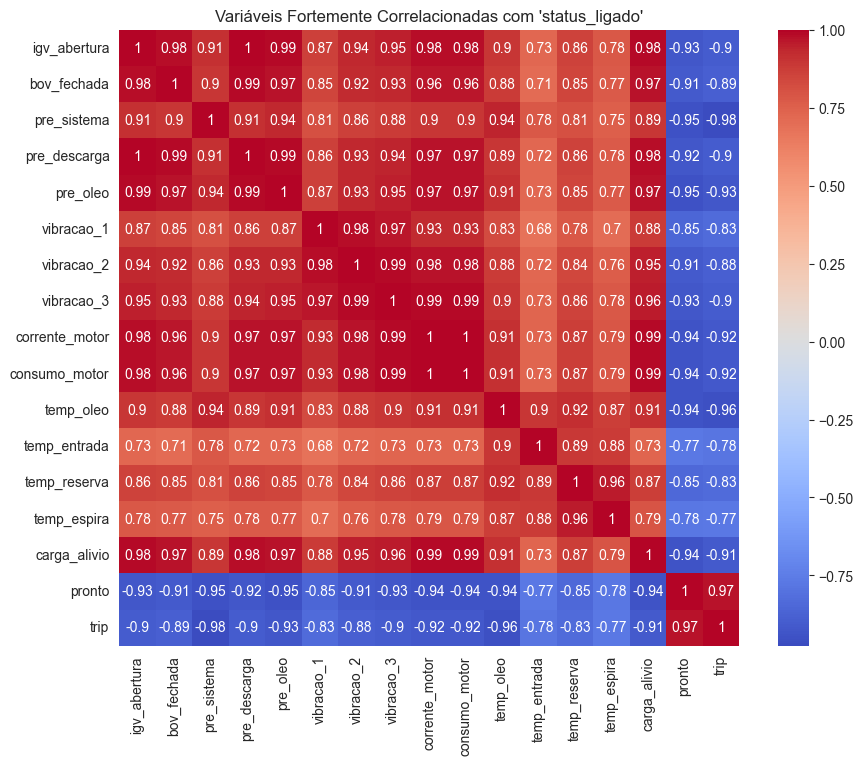

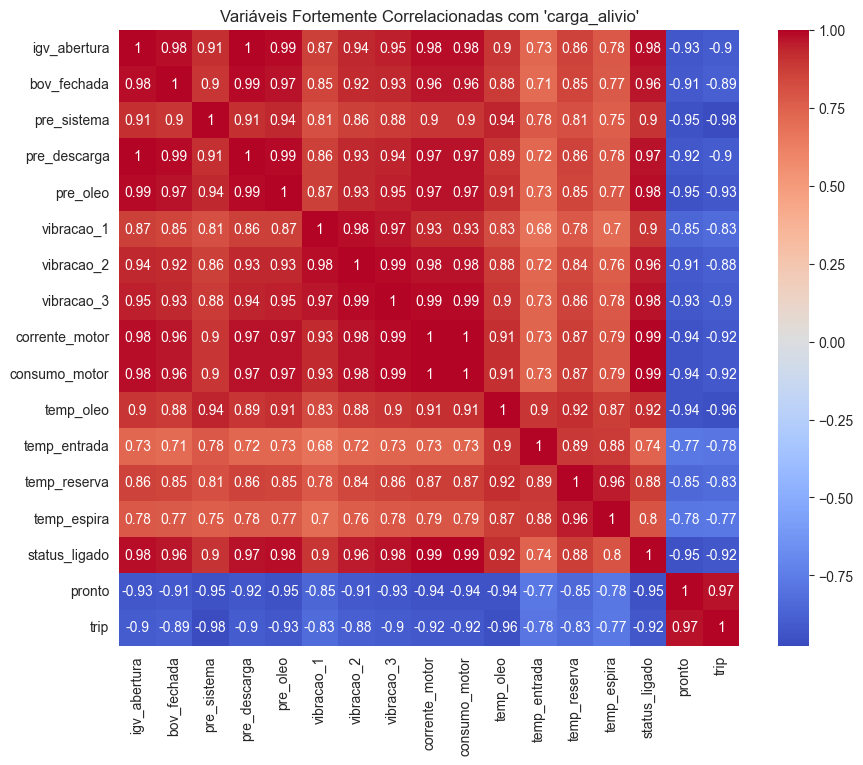

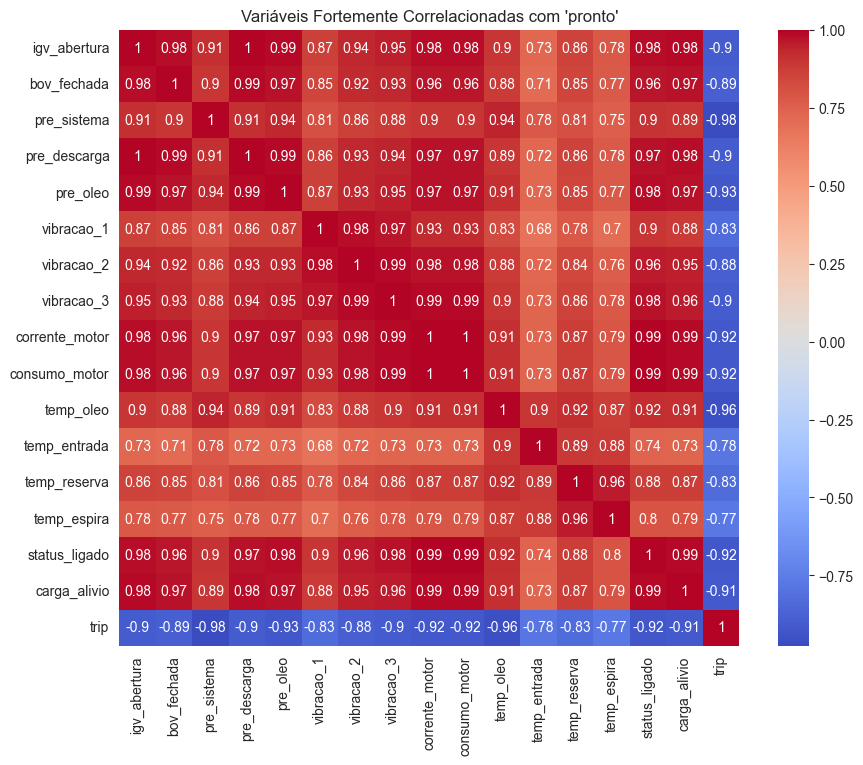

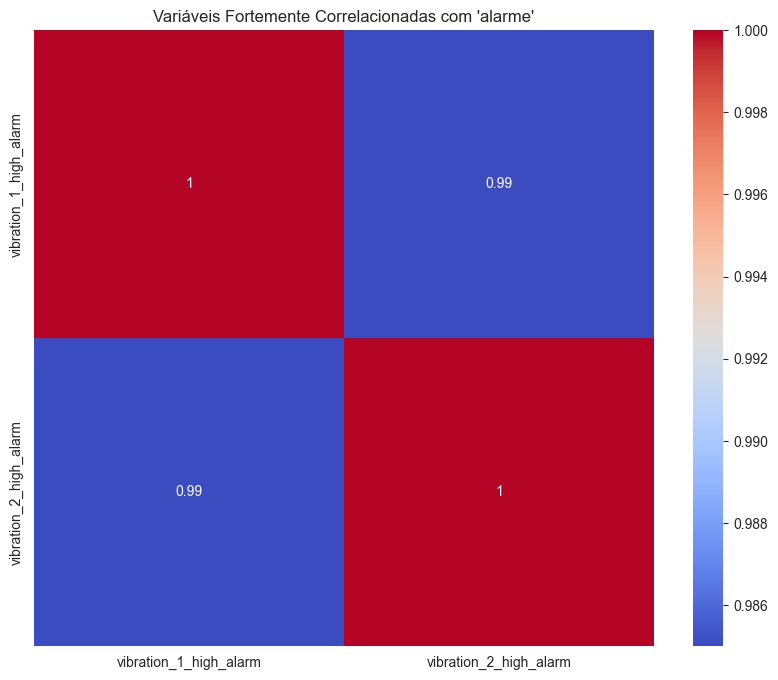

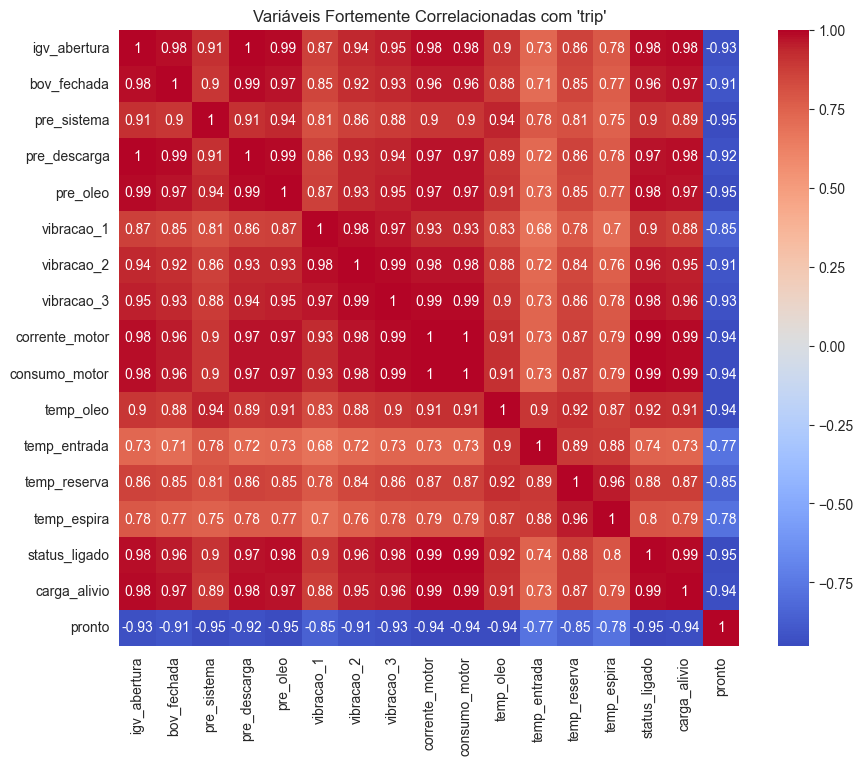

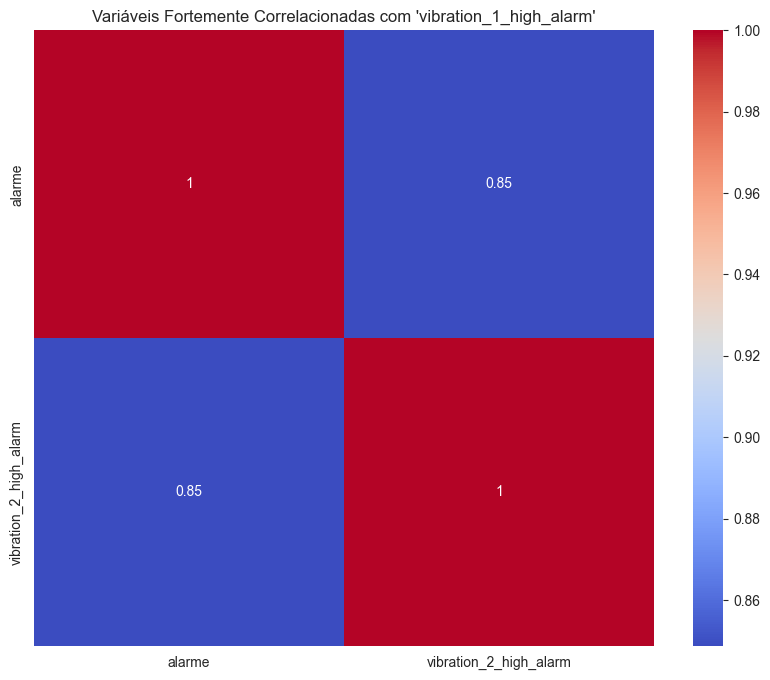

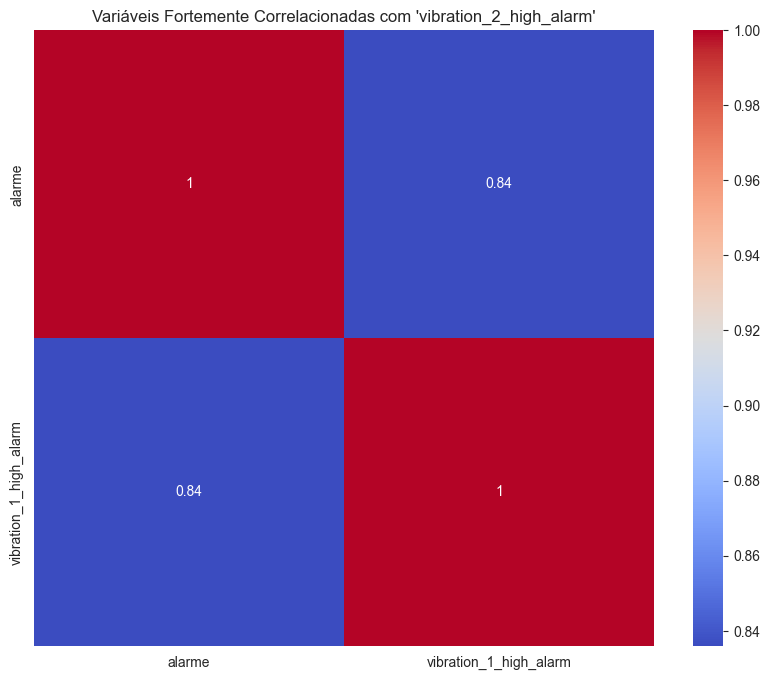

Processo de análise de correlação concluído para todas as colunas.


In [14]:
# Selecionar apenas colunas numéricas
df_numerico = df.select_dtypes(include=['number'])

# Iterar sobre todas as colunas numéricas
for coluna in df_numerico.columns:
    if coluna != 'id':
        # Calcular a correlação apenas entre variáveis numéricas
        matriz_correlacao = df_numerico.corr()

        # Selecionar variáveis fortemente correlacionadas com a 'coluna' atual
        correlacoes = matriz_correlacao[coluna].dropna()
        fortes = correlacoes[abs(correlacoes) > 0.5].drop(coluna, errors='ignore') # Remove a própria coluna

        # Criar novo heatmap apenas se houver variáveis fortemente correlacionadas
        if not fortes.empty:
            plt.figure(figsize=(10, 8))  # Ajuste o tamanho conforme necessário
            sns.heatmap(df[fortes.index].corr(), annot=True, cmap="coolwarm")
            plt.title(f"Variáveis Fortemente Correlacionadas com '{coluna}'")
            plt.show()
        else:
            print(f"Não foram encontradas variáveis fortemente correlacionadas com '{coluna}' (correlação absoluta > 0.5).")

print("Processo de análise de correlação concluído para todas as colunas.")


Nenhuma variável fortemente correlacionada (abs > 0.5) encontrada para 'unidade'.

Nenhuma variável fortemente correlacionada (abs > 0.5) encontrada para 'vida'.

Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'igv_abertura':


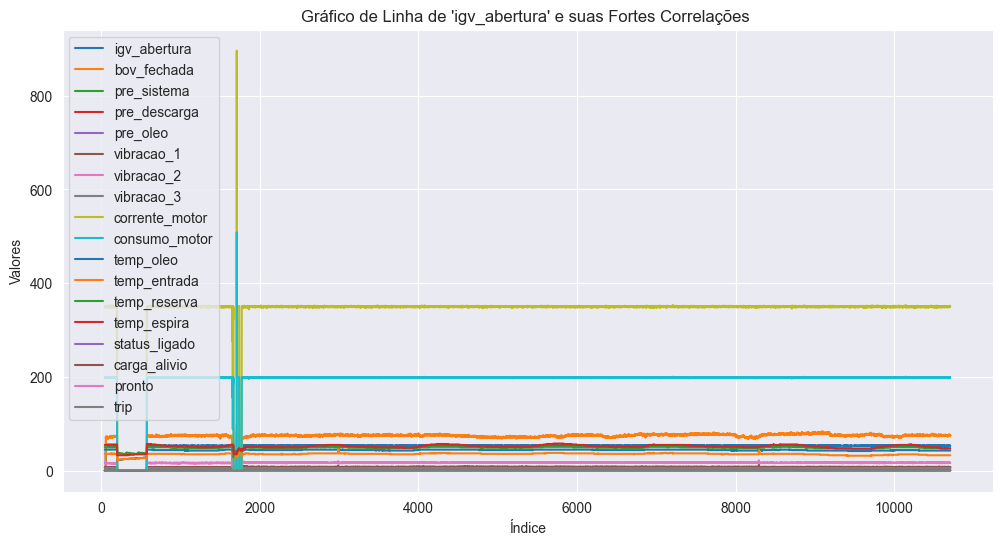


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'bov_fechada':


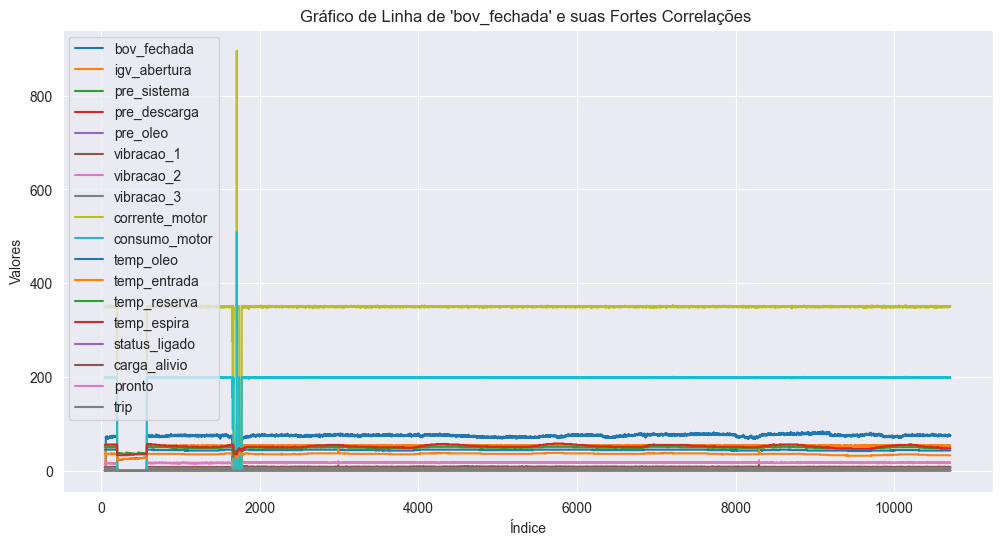


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'pre_sistema':


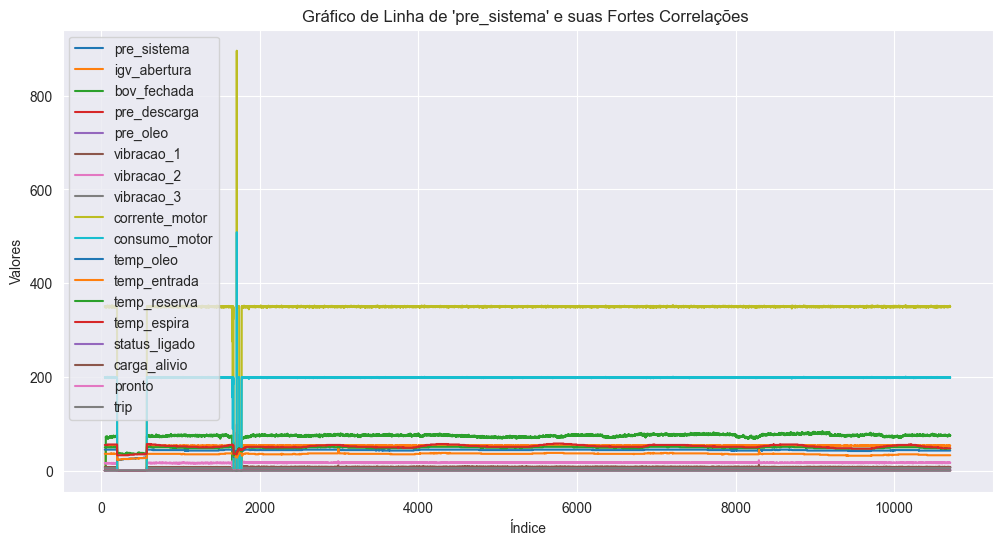


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'pre_descarga':


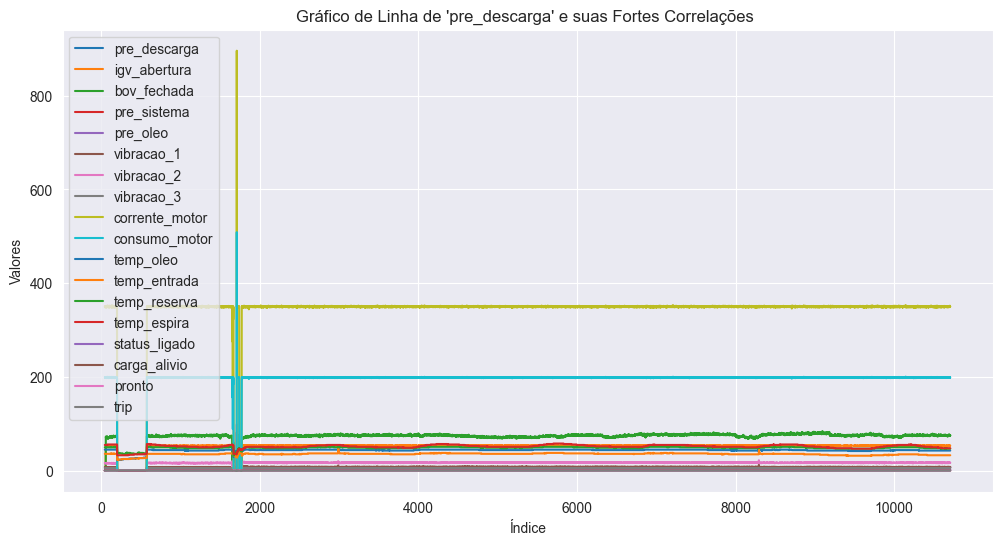


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'pre_oleo':


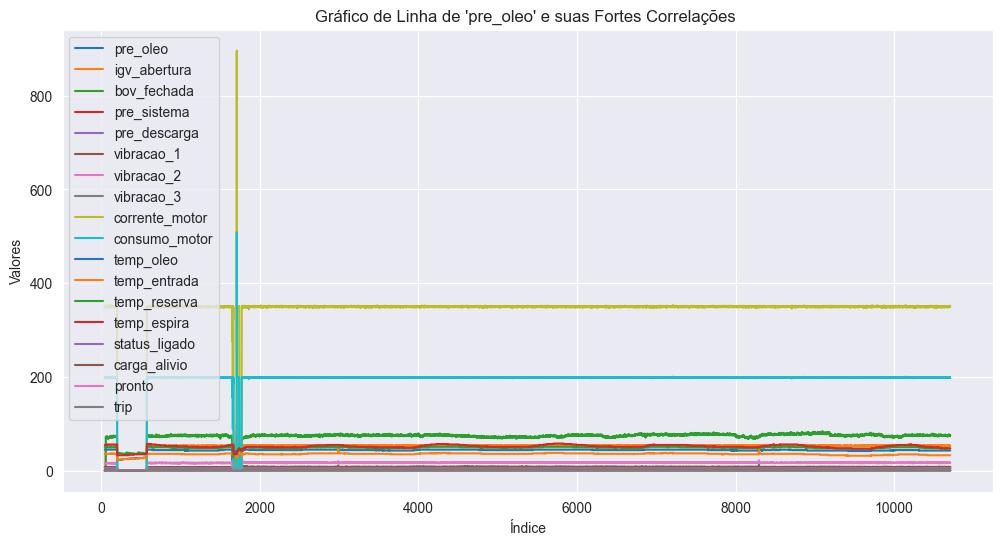


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'vibracao_1':


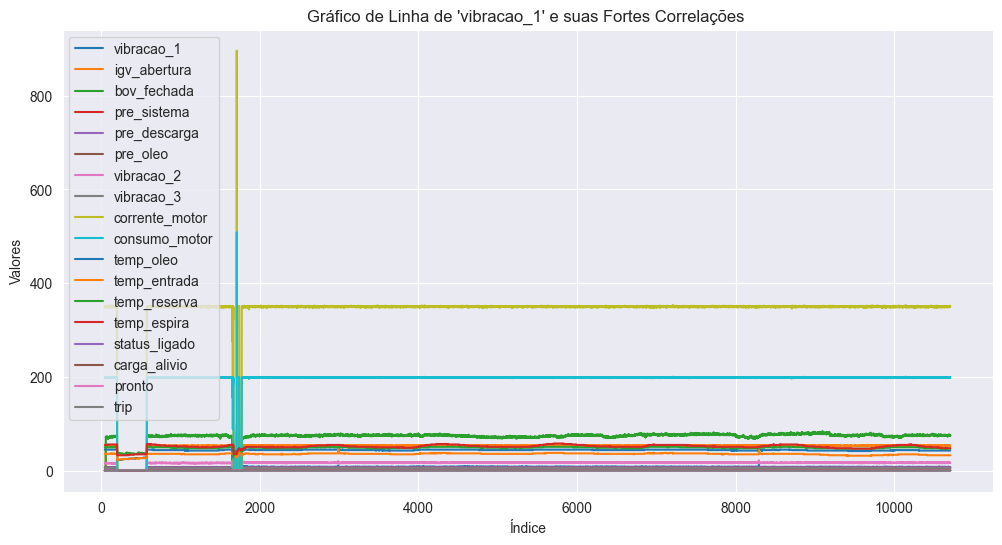


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'vibracao_2':


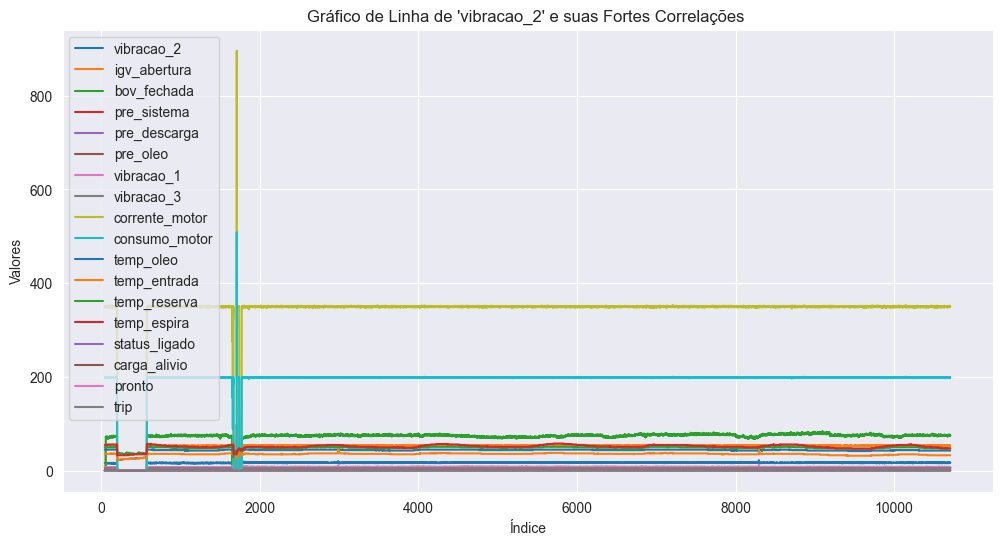


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'vibracao_3':


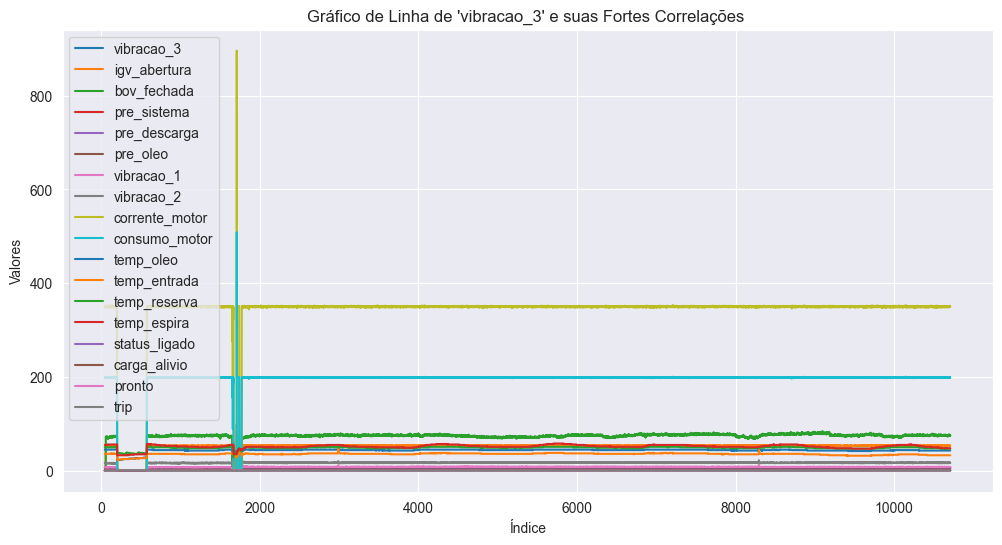


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'corrente_motor':


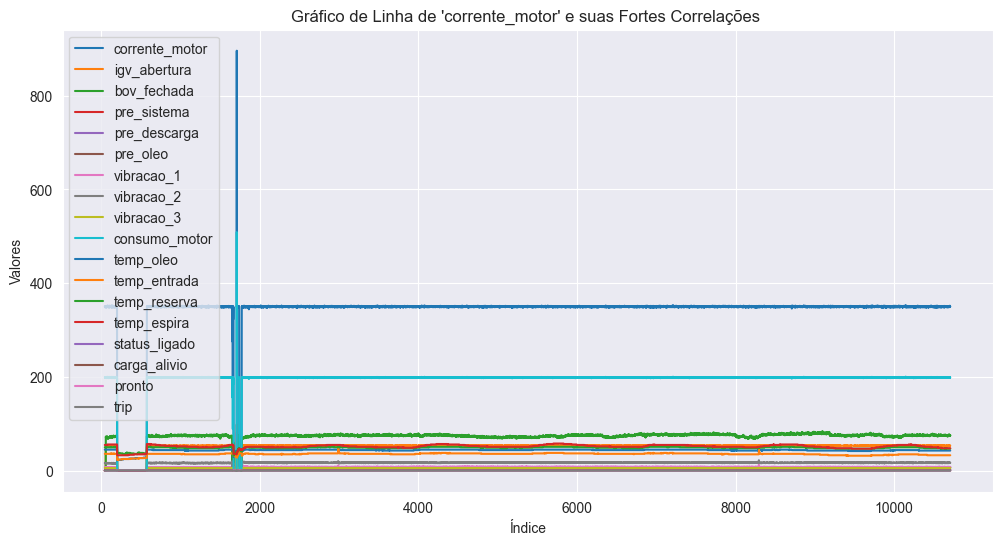


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'consumo_motor':


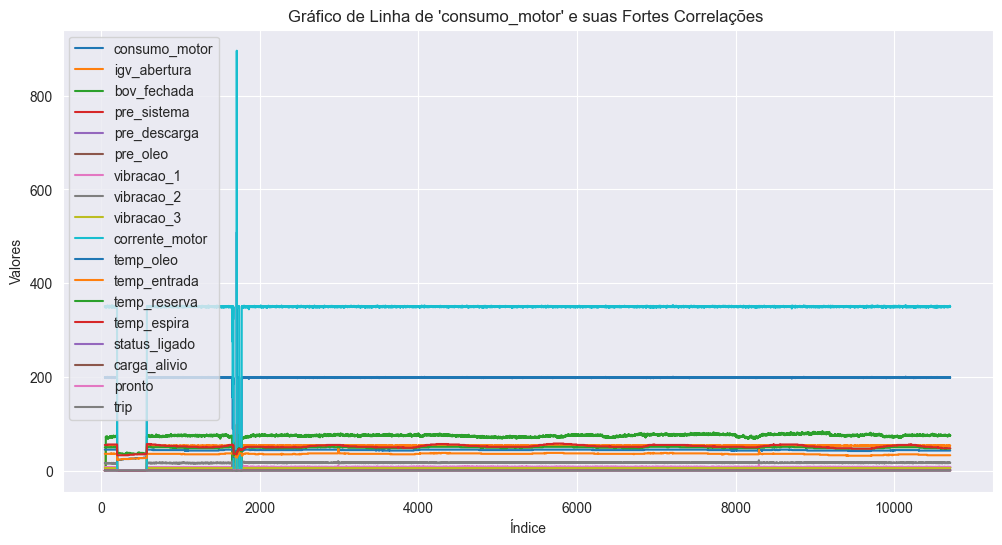


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'temp_oleo':


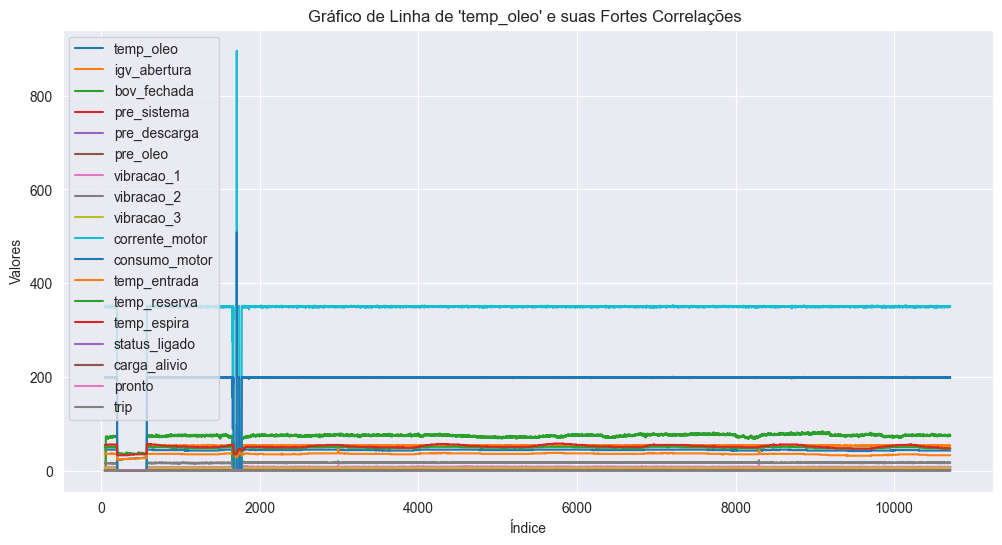


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'temp_entrada':


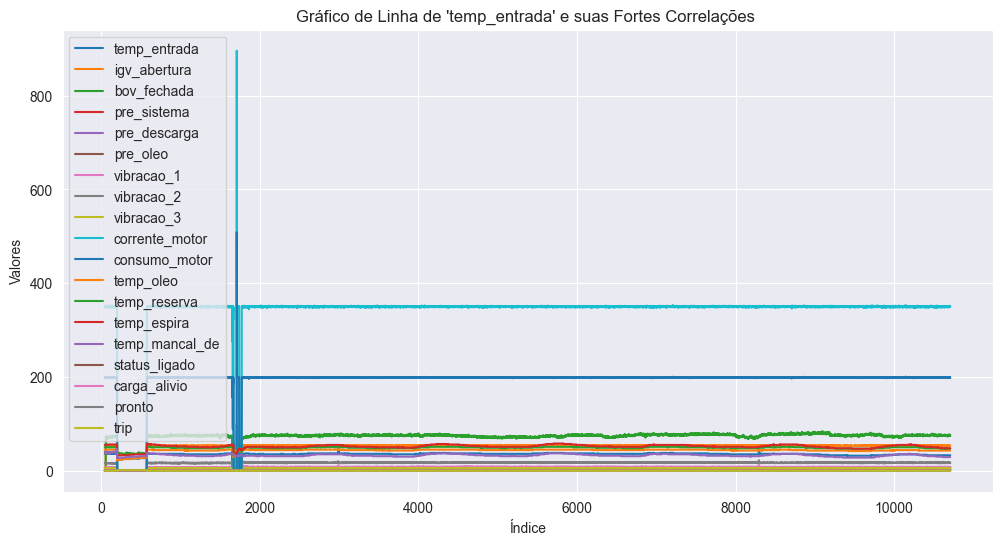


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'temp_reserva':


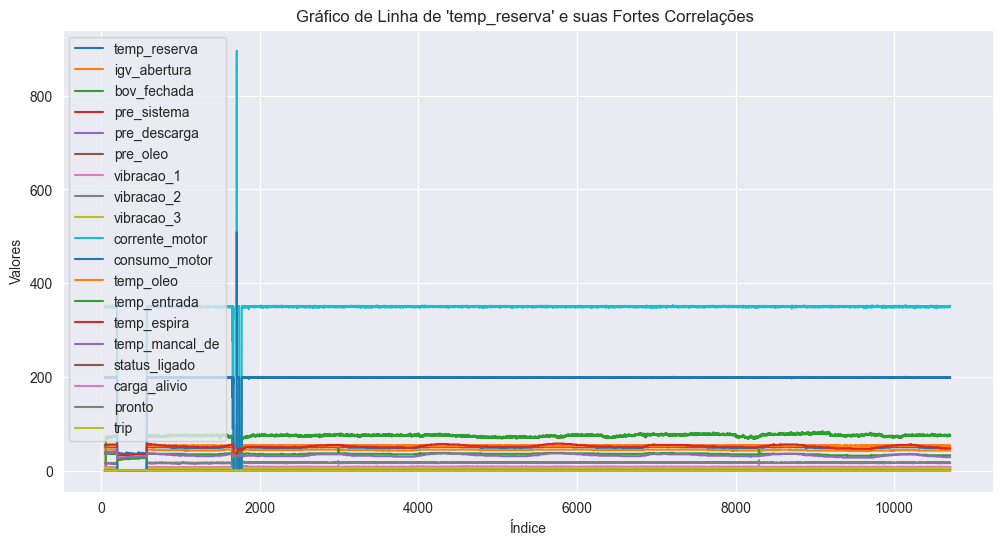


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'temp_espira':


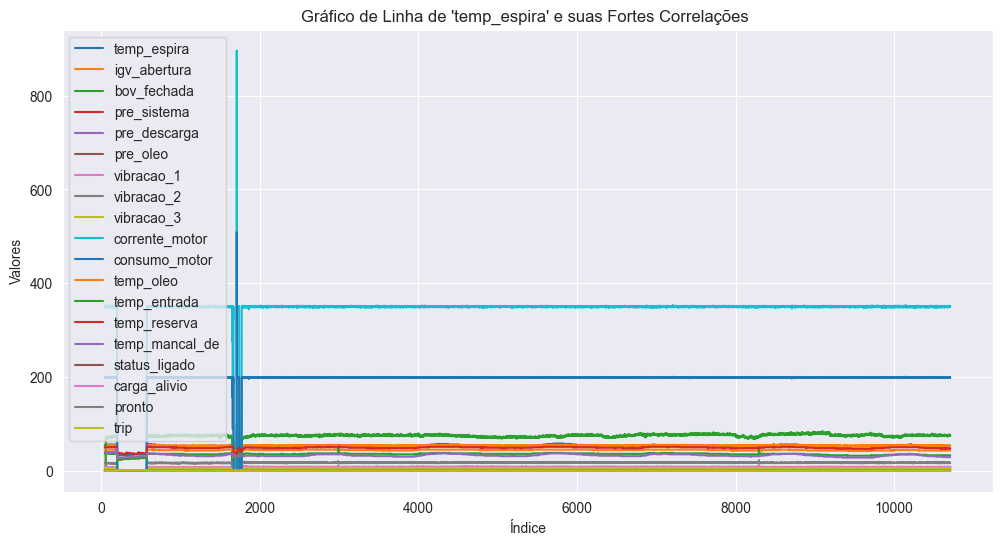


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'temp_mancal_de':


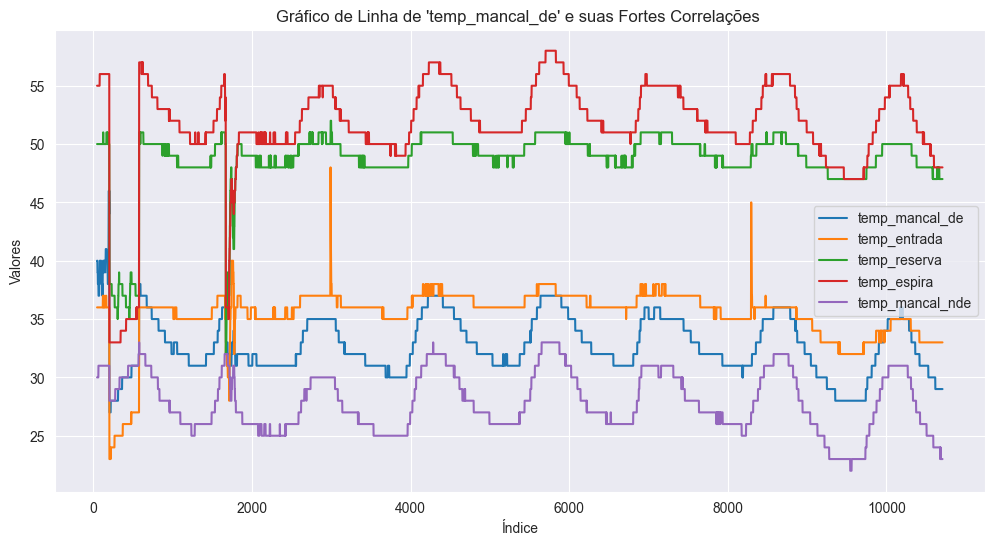


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'temp_mancal_nde':


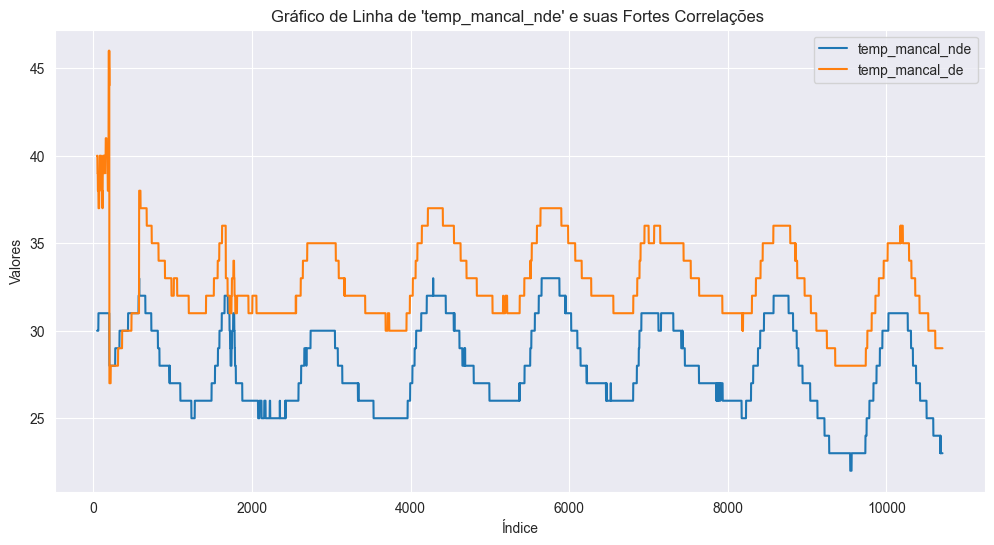


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'hs_trabalhadas':


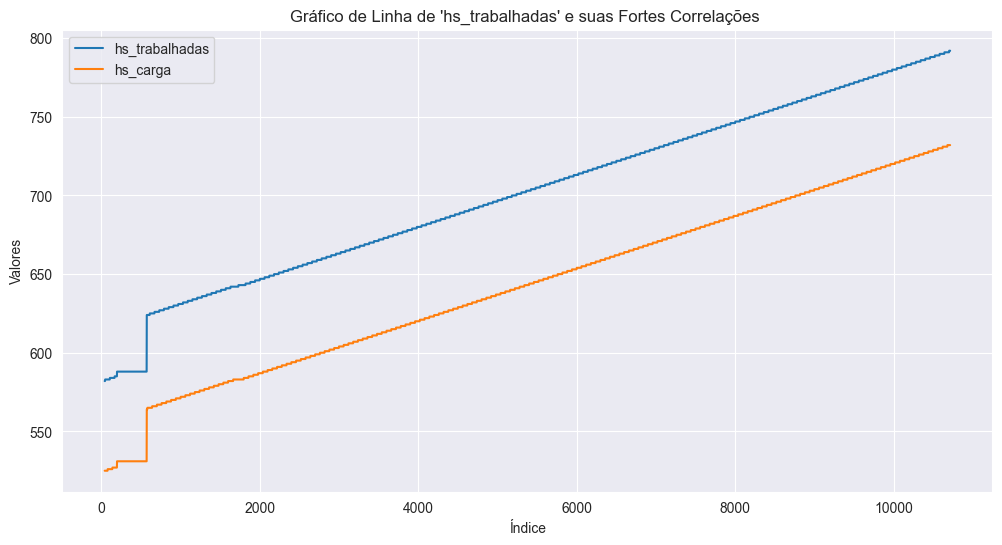


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'hs_carga':


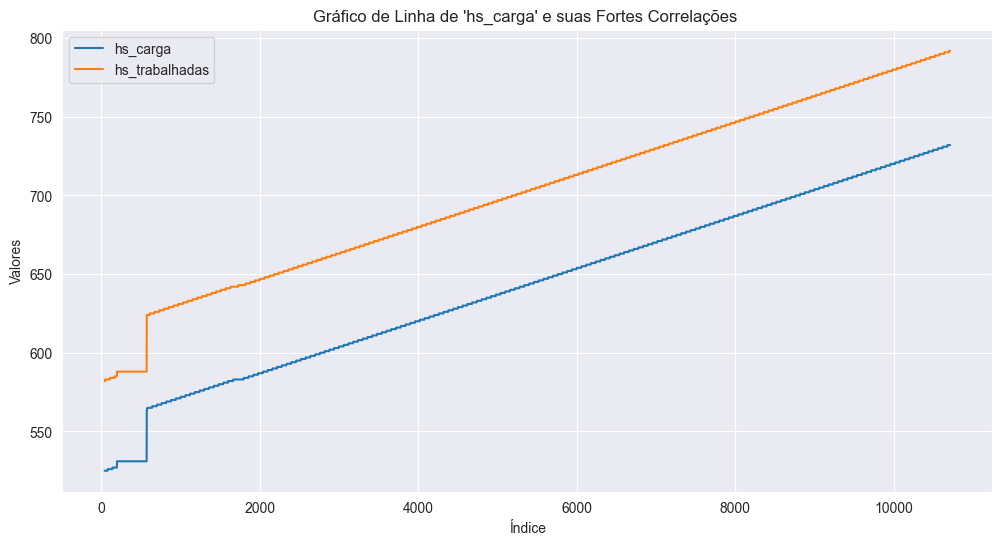


Nenhuma variável fortemente correlacionada (abs > 0.5) encontrada para 'pre_setpoint'.

Nenhuma variável fortemente correlacionada (abs > 0.5) encontrada para 'pre_unloadsp'.

Nenhuma variável fortemente correlacionada (abs > 0.5) encontrada para 'pre_reloadsp'.

Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'status_ligado':


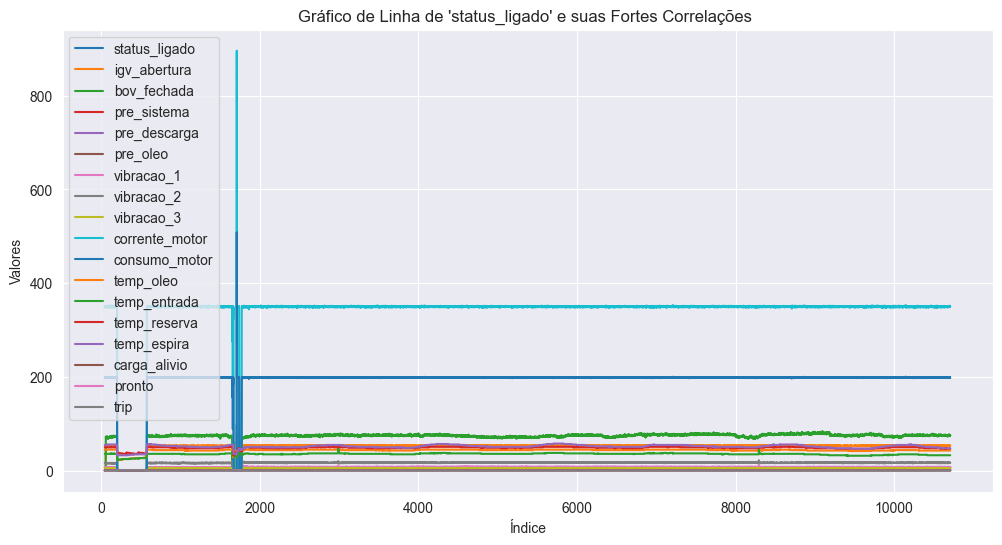


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'carga_alivio':


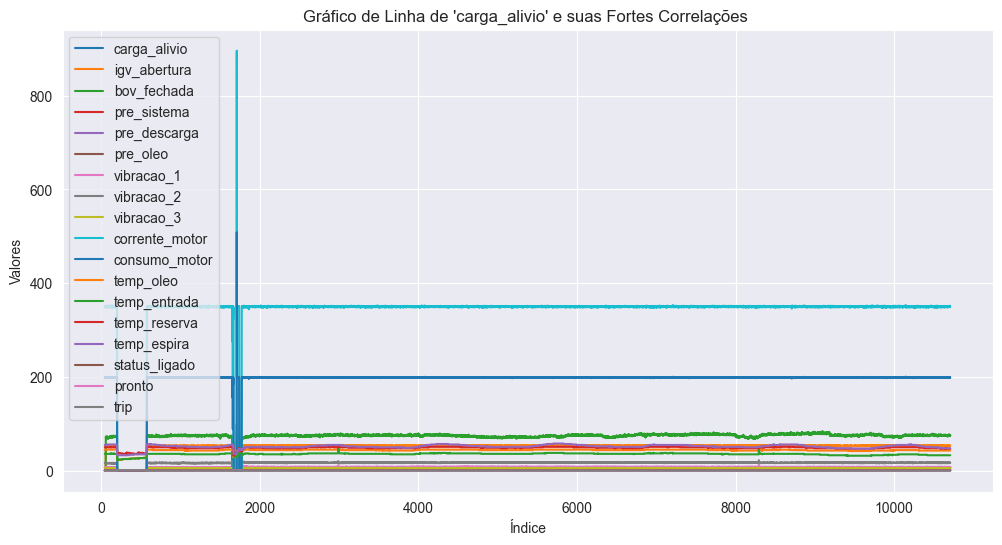


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'pronto':


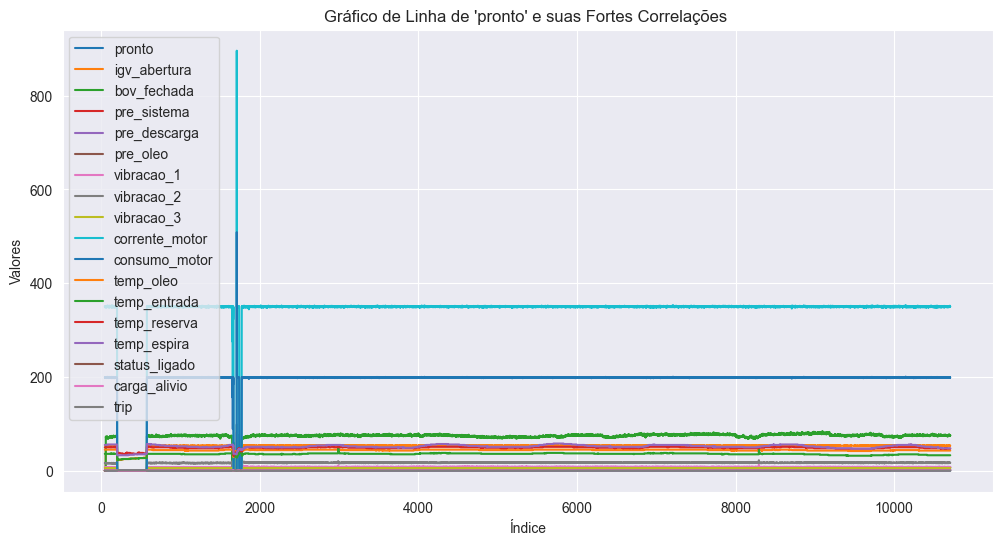


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'alarme':


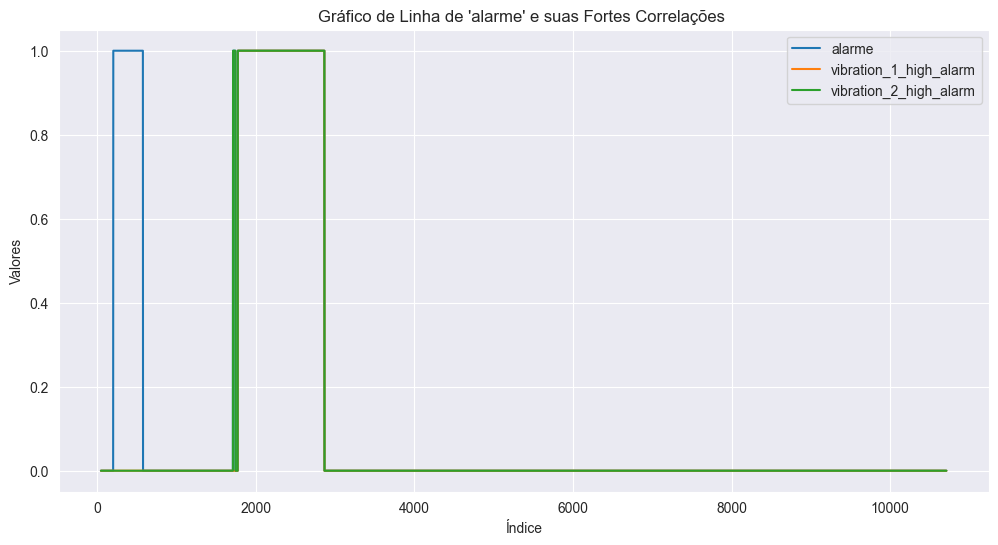


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'trip':


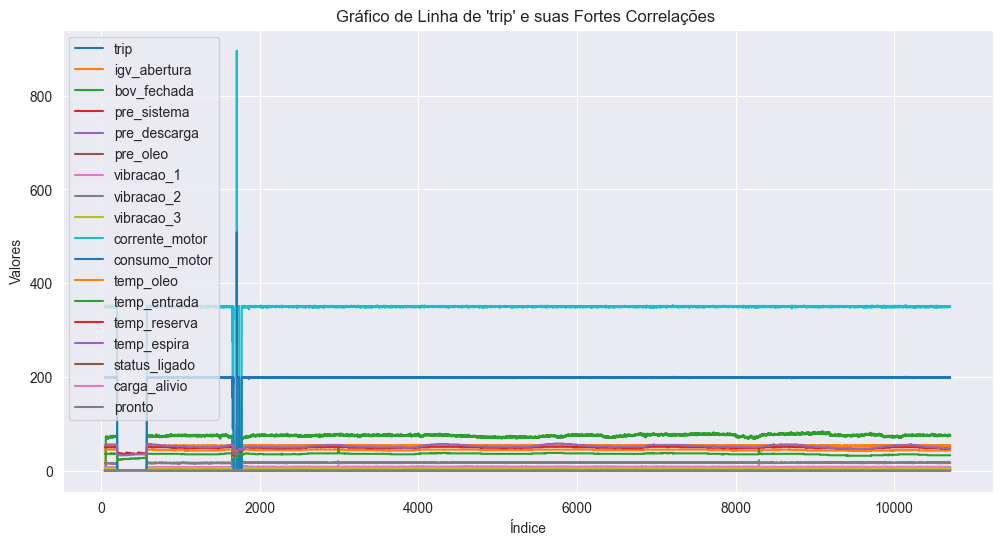


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'vibration_1_high_alarm':


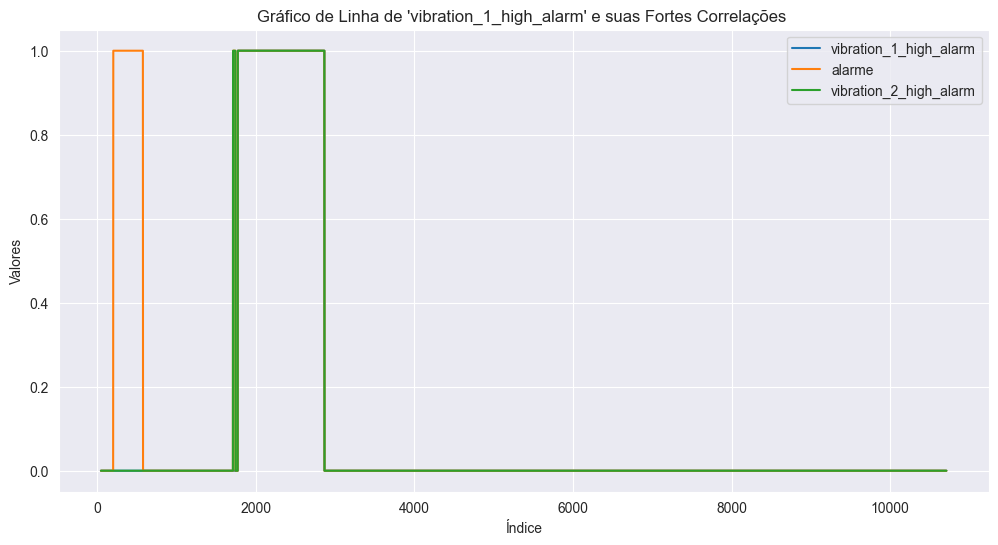


Gráficos de Linha para Variáveis Fortemente Correlacionadas com 'vibration_2_high_alarm':


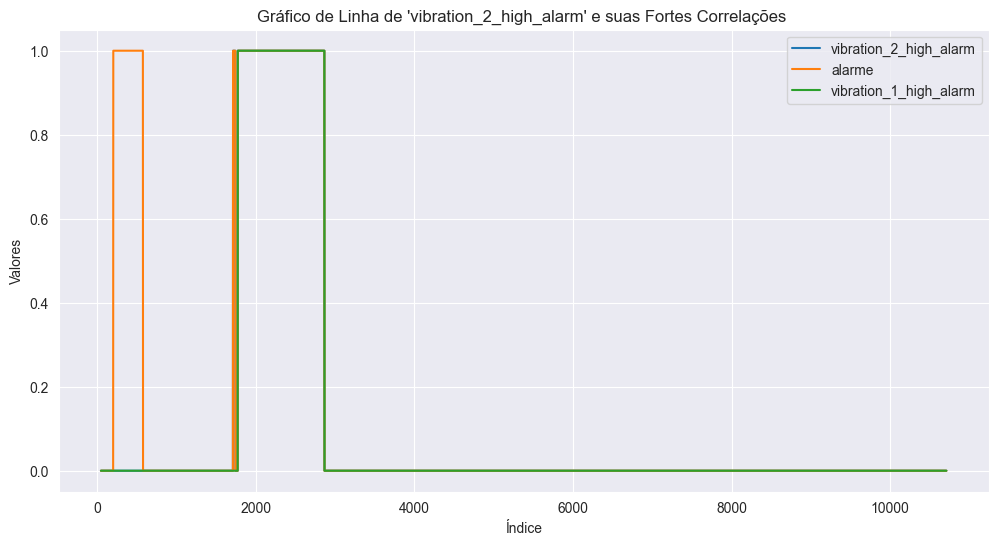


Processo de geração de gráficos de linha concluído.


In [15]:
# Selecionar apenas colunas numéricas
df_numerico = df.select_dtypes(include=['number']).copy() 

# Remover a coluna 'vida' para evitar analisar a correlação consigo mesma
if 'id' in df_numerico.columns:
    df_numerico = df_numerico.drop(columns=['id'])

# Iterar sobre as colunas restantes
for coluna_referencia in df_numerico.columns:
    # Calcular a correlação da coluna de referência com as outras colunas numéricas
    correlacoes = df_numerico.corr()[coluna_referencia].dropna()

    # Selecionar as colunas fortemente correlacionadas (abs(correlação) > 0.5)
    fortes = correlacoes[abs(correlacoes) > 0.5].drop(coluna_referencia, errors='ignore')

    if not fortes.empty:
        print(f"\nGráficos de Linha para Variáveis Fortemente Correlacionadas com '{coluna_referencia}':")
        plt.figure(figsize=(12, 6))
        plt.plot(df.index, df[coluna_referencia], label=coluna_referencia) # Plot da coluna de referência

        for coluna_forte in fortes.index:
            plt.plot(df.index, df[coluna_forte], label=coluna_forte)

        plt.xlabel("Índice")
        plt.ylabel("Valores")
        plt.title(f"Gráfico de Linha de '{coluna_referencia}' e suas Fortes Correlações ")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"\nNenhuma variável fortemente correlacionada (abs > 0.5) encontrada para '{coluna_referencia}'.")

print("\nProcesso de geração de gráficos de linha concluído.")